# NB02 — Análisis Exploratorio de Datos (EDA)
## Proyecto: `siniestralidad-vial-sv`

Este notebook corresponde a la **Fase 3 (Preparación de datos — componente exploratorio)** de
CRISP-DM 

Ubicación en el pipeline:

- **NB01** — describió y validó la materia prima (calibración vs ONASEVI/FONAT 2022–2025,
  integridad, completitud de fuentes). *Hecho.*
- **NB02 (este)** — explora los datos, demuestra empíricamente los patrones documentados y
  extrae las decisiones que condicionan el modelado.
- **NB03** — preprocesamiento y *feature engineering* reproducible (grilla
  distrito×fecha×franja, *joins* formales, *targets*).
- **NB04** — modelos baseline + tabla comparativa + interpretabilidad.

Toda la configuración (rutas, semilla, cargadores) se importa desde `src/config.py`.
En este notebook **no se redefinen rutas ni la semilla**: se reutiliza `cfg`.

### Objetivo del notebook

Caracterizar la distribución espacio-temporal, causal y de severidad de la siniestralidad
vial en El Salvador (2022–jun 2026) y justificar con evidencia las decisiones de modelado que
se implementan en NB03 y NB04.

### Alcance y frontera con NB03

Este es un notebook **exploratorio**. Algunas visualizaciones (sobredispersión, relación
clima–siniestralidad, tasa per cápita) requieren **agregaciones o *joins* ligeros** para poder
observarse. Cuando eso ocurra:

- El *join* o la agregación se realiza **de forma local y explícitamente marcada como
  exploratoria**, con el único fin de visualizar.
- **No** se construye aquí la grilla formal `distrito×fecha×franja` con celdas en cero, ni las
  *features* definitivas: eso pertenece a **NB03**, donde el proceso es reproducible y
  versionado.

NB02 *muestra* que la señal existe; NB03 la *construye* correctamente para modelar.

### Nota sobre la naturaleza de los datos

El conjunto combina fuentes de **naturaleza distinta**:

- **Sintético calibrado** — solo la capa de eventos: `siniestros` y `victimas`, calibrados a
  los agregados oficiales de ONASEVI/FONAT (totales anuales 2022–2025) y repartidos
  espacialmente por **exposición real** (población Censo 2024 × urbanización × densidad
  vehicular).
- **Real oficial** — el resto: `censo_poblacion_distrito` (Censo 2024, BCR/ONEC),
  `feriados_elsalvador_2022_2026` (calendario oficial) y el clima horario de Meteostat.

Como la capa de eventos es sintética calibrada, el EDA sobre ella refleja la estructura con la
que fue construida; por eso este notebook trata los patrones temporales, espaciales y causales
como **caracterización del dato de trabajo** y no como hallazgos epidemiológicos nuevos. Las
variables de exposición, calendario y clima sí son reales, de modo que su cruce con la
siniestralidad es un ejercicio híbrido (señal calibrada × contexto real). Esta aclaración se
hace **una vez aquí** y no se repite sección por sección.

## 1. Panorama general

Antes del análisis detallado se establece una vista mínima del conjunto para fijar dimensiones
y ventana temporal. Esta sección **no duplica** la validación de calidad e integridad ya
realizada en NB01 (calibración, duplicados, huérfanas, coordenadas, consistencia víctimas):
aquí solo se confirman las magnitudes de trabajo del EDA.

Se reporta:

- Dimensiones de `siniestros` (89.946 registros) y `victimas` (60.402 registros).
- Ventana temporal efectiva y su distribución por año.
- Recordatorio de que **~52 % de los siniestros no tienen víctimas** (solo daños materiales):
  es un rasgo realista del dato, no un error, y obliga a analizar la severidad en dos universos
  (todos los siniestros vs solo con víctimas).

### Cobertura temporal y el año 2026 (parcial)

La ventana abarca **enero 2022 – junio 2026**. El año **2026 está incompleto** (solo ene–jun,
marcado en el dato con `registro_parcial = 'Si'`: 11.509 siniestros). Esto tiene consecuencias
directas sobre cómo se grafica cada serie temporal.

Criterio adoptado en este notebook (se detalla y se justifica en la Sección 3):

- En **totales anuales absolutos**, 2026 se **incluye diferenciado** (color/trama distinta +
  asterisco), nunca comparado de igual a igual con años completos.
- En **tendencias como línea**, el tramo 2026 se dibuja **punteado** o se corta en 2025.
- Para cualquier **comparación seria** de 2026 se usa el **semestre homólogo** (ene–jun vs
  ene–jun de años previos).
- En gráficos **intra-anuales** (mes, día de semana, franja horaria), 2026 se **incluye
  completo y sin marca**, normalizando por promedio (no por suma), porque ahí no distorsiona la
  forma del patrón.

Esta decisión evita el artefacto visual de una "caída" falsa de la siniestralidad en la última
barra, preservando el dato real y demostrando comprensión del sesgo del propio conjunto.

In [2]:
# --- Setup de path del proyecto ---
# El notebook corre desde notebooks/, pero src/ está en la raíz.
# Se agrega la raíz al sys.path para poder importar src/config.py.
import sys
from pathlib import Path


def _find_root(start: Path) -> Path:
    """Sube desde el cwd hasta encontrar la raíz del proyecto (con src/config.py)."""
    for p in [start, *start.parents]:
        if (p / "src" / "config.py").exists():
            return p
    raise FileNotFoundError("No encontré la raíz del proyecto (src/config.py).")


ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Imports base ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Configuración del proyecto (rutas, semilla, loaders) ---
# Toda la configuración vive en src/config.py; aquí NO se redefine nada.
from src import config as cfg  # noqa: E402

# --- Estética de gráficos (consistente para todo el notebook) ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"]   = (10, 5)
plt.rcParams["figure.dpi"]       = 110
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"]   = 11
plt.rcParams["font.size"]        = 10

# Paleta base y color reservado para marcar datos parciales (2026)
COLOR_PRINCIPAL = "#2C6E9B"   # azul para series completas
COLOR_PARCIAL   = "#B0B0B0"   # gris para el tramo/barra parcial (2026)
COLOR_ACENTO    = "#C0392B"   # rojo para resaltar (picos, alertas)

# Formato de números para lectura (miles con separador)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Proyecto:", cfg.ROOT_DIR.name)
print("Raíz    :", cfg.ROOT_DIR)
print("Seed    :", cfg.SEED)
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)

Proyecto: siniestralidad-vial-sv
Raíz    : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv
Seed    : 42
pandas  : 2.2.2
numpy   : 1.26.4


In [3]:
# --- Carga de las 6 fuentes vía loaders de config ---
# Cada loader ya aplica el parseo/limpieza acordado en NB01.

siniestros = cfg.load_siniestros()    # eventos: fecha, hora, franja, distrito, GPS, categóricas, severidad
victimas   = cfg.load_victimas()      # personas enlazadas por id_siniestro
censo      = cfg.load_censo()         # población real Censo 2024 (262 distritos) + urbano/rural
estaciones = cfg.load_estaciones()    # catálogo de estaciones meteorológicas (id WMO + lat/lon)
feriados   = cfg.load_feriados()      # calendario oficial de feriados 2022–2026
clima      = cfg.load_clima_all()     # clima horario unificado (todas las estaciones, columna 'time')

# --- Confirmación de carga: forma de cada fuente ---
fuentes = {
    "siniestros": siniestros,
    "victimas":   victimas,
    "censo":      censo,
    "estaciones": estaciones,
    "feriados":   feriados,
    "clima":      clima,
}

print("Fuentes cargadas correctamente:\n")
for nombre, df in fuentes.items():
    print(f"  {nombre:<12} -> {df.shape[0]:>8,} filas  x  {df.shape[1]:>2} columnas")

Fuentes cargadas correctamente:

  siniestros   ->   89,946 filas  x  23 columnas
  victimas     ->   60,402 filas  x   9 columnas
  censo        ->      262 filas  x   7 columnas
  estaciones   ->        7 filas  x   8 columnas
  feriados     ->       70 filas  x   8 columnas
  clima        ->  225,227 filas  x  24 columnas


In [4]:
# --- Dimensiones de las capas de eventos ---
print("Dimensiones de las capas de eventos")
print(f"  siniestros : {siniestros.shape[0]:>8,} filas  x  {siniestros.shape[1]:>2} columnas")
print(f"  victimas   : {victimas.shape[0]:>8,} filas  x  {victimas.shape[1]:>2} columnas")

# --- Universo con víctimas vs solo daños materiales ---
# Un siniestro tiene víctimas si registró al menos un fallecido o lesionado.
# (En NB01 se verificó que fallecidos + lesionados == n_victimas, sin inconsistencias.)
sin_victimas = (siniestros["fallecidos"] + siniestros["lesionados"]) == 0
n_sin  = int(sin_victimas.sum())
n_con  = int((~sin_victimas).sum())
total  = len(siniestros)

print("\nUniverso de siniestros según severidad")
print(f"  Con víctimas (fallecido/lesionado) : {n_con:>8,}  ({n_con/total:6.1%})")
print(f"  Solo daños materiales              : {n_sin:>8,}  ({n_sin/total:6.1%})")
print(f"  Total                              : {total:>8,}  (100.0%)")

Dimensiones de las capas de eventos
  siniestros :   89,946 filas  x  23 columnas
  victimas   :   60,402 filas  x   9 columnas

Universo de siniestros según severidad
  Con víctimas (fallecido/lesionado) :   43,105  ( 47.9%)
  Solo daños materiales              :   46,841  ( 52.1%)
  Total                              :   89,946  (100.0%)


In [5]:
# --- Ventana temporal efectiva ---
fecha_min = siniestros["fecha"].min()
fecha_max = siniestros["fecha"].max()
print("Ventana temporal de los siniestros")
print(f"  Desde : {fecha_min:%Y-%m-%d}")
print(f"  Hasta : {fecha_max:%Y-%m-%d}")

# --- Distribución por año (marcando 2026 como parcial) ---
sini = siniestros.copy()
sini["anio"] = sini["fecha"].dt.year

# Un año se considera parcial si TODOS sus registros están marcados registro_parcial='Si'
resumen_anual = (
    sini.groupby("anio")
        .agg(
            siniestros = ("id_siniestro", "size"),
            fallecidos = ("fallecidos", "sum"),
            lesionados = ("lesionados", "sum"),
            parcial    = ("registro_parcial", lambda s: (s == "Si").any()),
        )
        .reset_index()
)

# Etiqueta visible del año parcial
resumen_anual["anio_lbl"] = resumen_anual.apply(
    lambda r: f"{r['anio']} *" if r["parcial"] else str(r["anio"]), axis=1
)

print("\nDistribución anual de siniestros (* = año parcial, solo ene–jun)")
print(
    resumen_anual[["anio_lbl", "siniestros", "fallecidos", "lesionados"]]
    .to_string(index=False)
)

Ventana temporal de los siniestros
  Desde : 2022-01-01
  Hasta : 2026-06-30

Distribución anual de siniestros (* = año parcial, solo ene–jun)
anio_lbl  siniestros  fallecidos  lesionados
    2022       17408        1352       10385
    2023       18463        1256       11015
    2024       20301        1303       11954
    2025       22265        1238       13285
  2026 *       11509         734        7880


## 2. Análisis univariado de siniestros

Se describe la distribución individual de las variables del evento, sin cruzarlas todavía. El
objetivo es conocer la composición del dato —qué tipos de vía, siniestro, vehículo y condiciones
predominan— antes de pasar a los patrones temporales (Sección 3) y espaciales (Sección 4).

El análisis se organiza en tres bloques:

- **2.1 — Variables categóricas descriptivas**: zona, tipo de vía, tipo de siniestro, tipo de
  vehículo y condición de la vía.
- **2.2 — Factor causante**: se trata por separado por su mayor número de categorías.
- **2.3 — Severidad univariada**: distribución del número de fallecidos y lesionados por
  siniestro.

### 2.1. Variables categóricas descriptivas

Se examina la frecuencia de cada categoría en cinco variables del siniestro:

- `zona` — urbana vs rural.
- `tipo_via` — 4 categorías.
- `tipo_siniestro` — 5 categorías (colisión, atropello, vuelco, etc.).
- `tipo_vehiculo` — 6 categorías del vehículo principal involucrado.
- `condicion_via` — estado de la superficie (seca, húmeda, con lodo/derrame).

Cada variable se presenta como conteo de siniestros por categoría, ordenado de mayor a menor.
La lectura busca dos cosas: identificar las categorías dominantes y detectar categorías poco
pobladas que puedan requerir agrupación en el *feature engineering* de NB03.

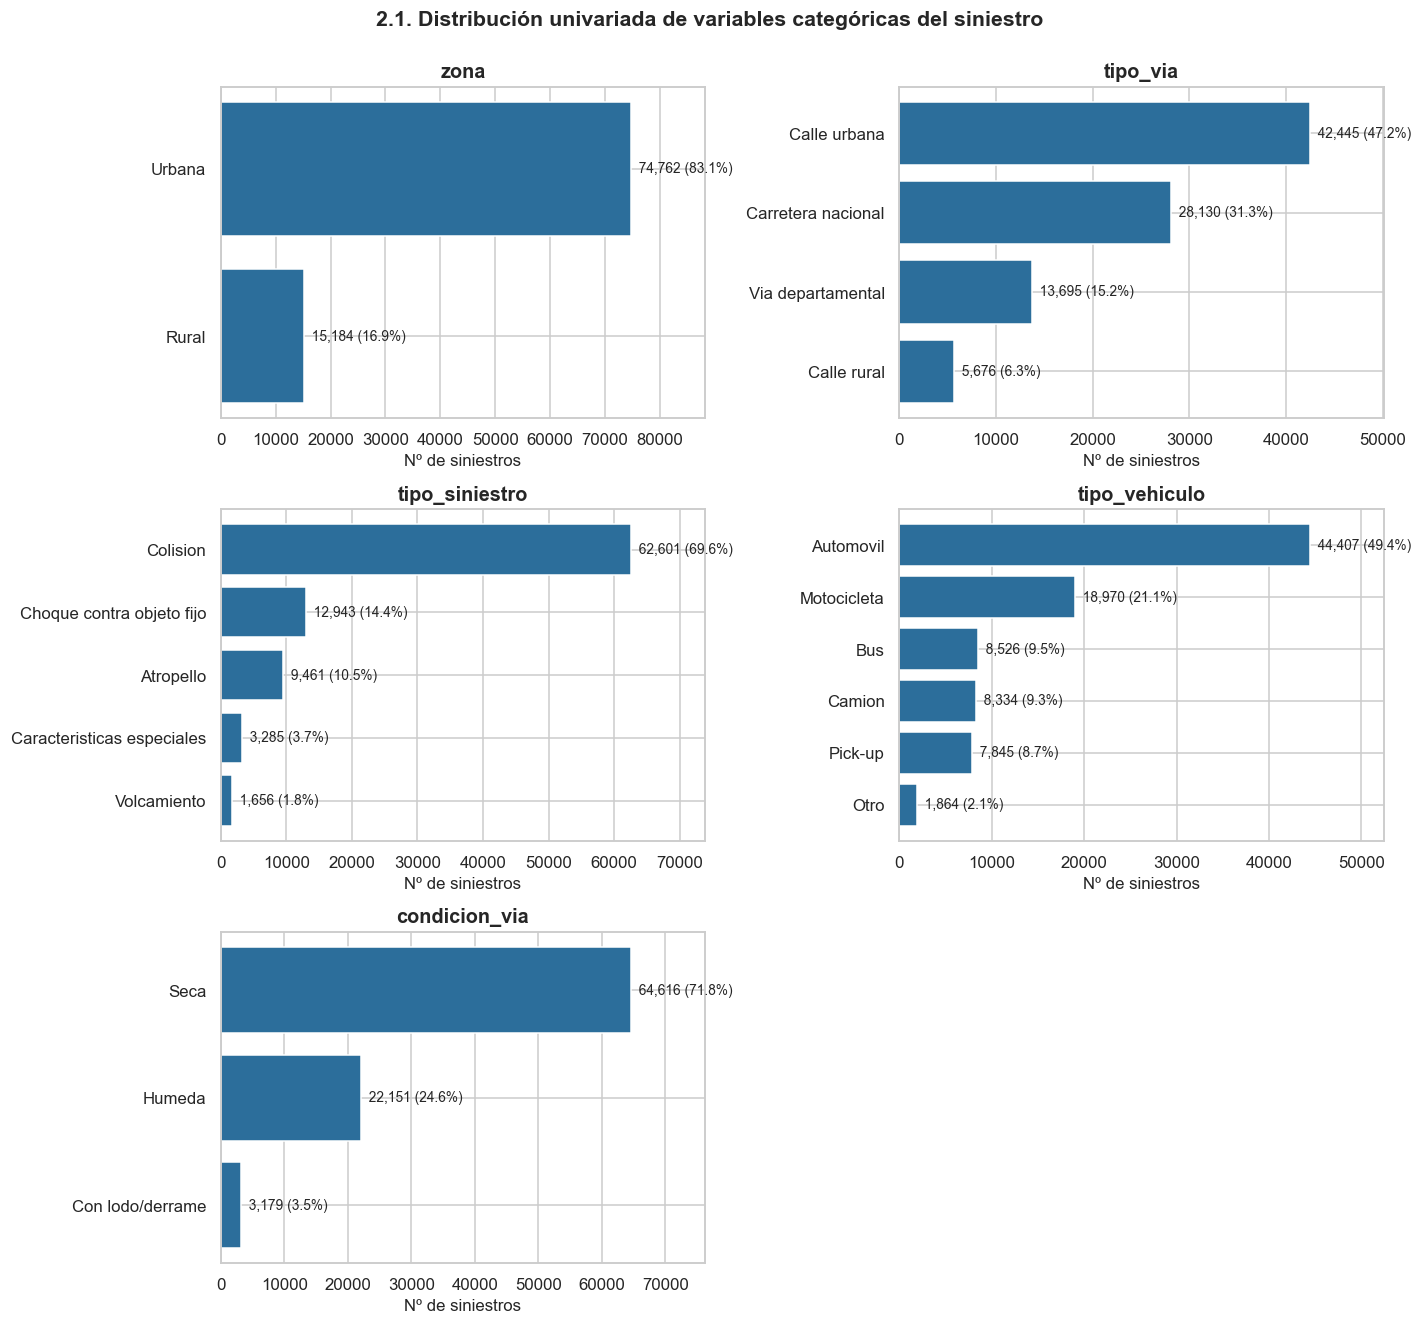

In [22]:
# --- Bloque 2.1: distribución univariada de categóricas descriptivas ---
cat_vars = ["zona", "tipo_via", "tipo_siniestro", "tipo_vehiculo", "condicion_via"]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    conteo = siniestros[col].value_counts().sort_values(ascending=True)
    pct = conteo / conteo.sum() * 100

    ax.barh(conteo.index.astype(str), conteo.values, color=COLOR_PRINCIPAL)
    ax.set_title(col)
    ax.set_xlabel("Nº de siniestros")

    # Etiqueta de conteo + porcentaje al final de cada barra
    for y, (v, p) in enumerate(zip(conteo.values, pct.values)):
        ax.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=9)

    # Margen a la derecha para que no se corten las etiquetas
    ax.set_xlim(0, conteo.max() * 1.18)

# El sexto subplot queda vacío (solo 5 variables): se oculta
axes[-1].axis("off")

fig.suptitle("2.1. Distribución univariada de variables categóricas del siniestro",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()

cfg.save_fig(fig, "nb02_2a_categoricas_descriptivas")
plt.show()

### 2.2. Factor causante

El `factor_causante` registra la causa principal atribuida al siniestro. A diferencia de las
variables del bloque 2A, presenta un número alto de categorías (17), por lo que se analiza por
separado con una barra horizontal ordenada que permita leer la cola larga de causas menos
frecuentes.

Interesa identificar:

- Las causas dominantes, que concentran la mayor parte de los siniestros.
- La cola de factores poco frecuentes, candidatos a agruparse en una categoría "otros" durante
  el *feature engineering* de NB03 para evitar categorías con soporte muy bajo.

6 de 17 categorías de factor_causante concentran ~80% de los siniestros.
Causas dentro del 80%: Distracción del Conductor, Invadir Carril, No Respetar Señales de Tránsito, No Guardar Distancia Reglamentaria, Estado de Ebriedad o Droga, Velocidad Excesiva


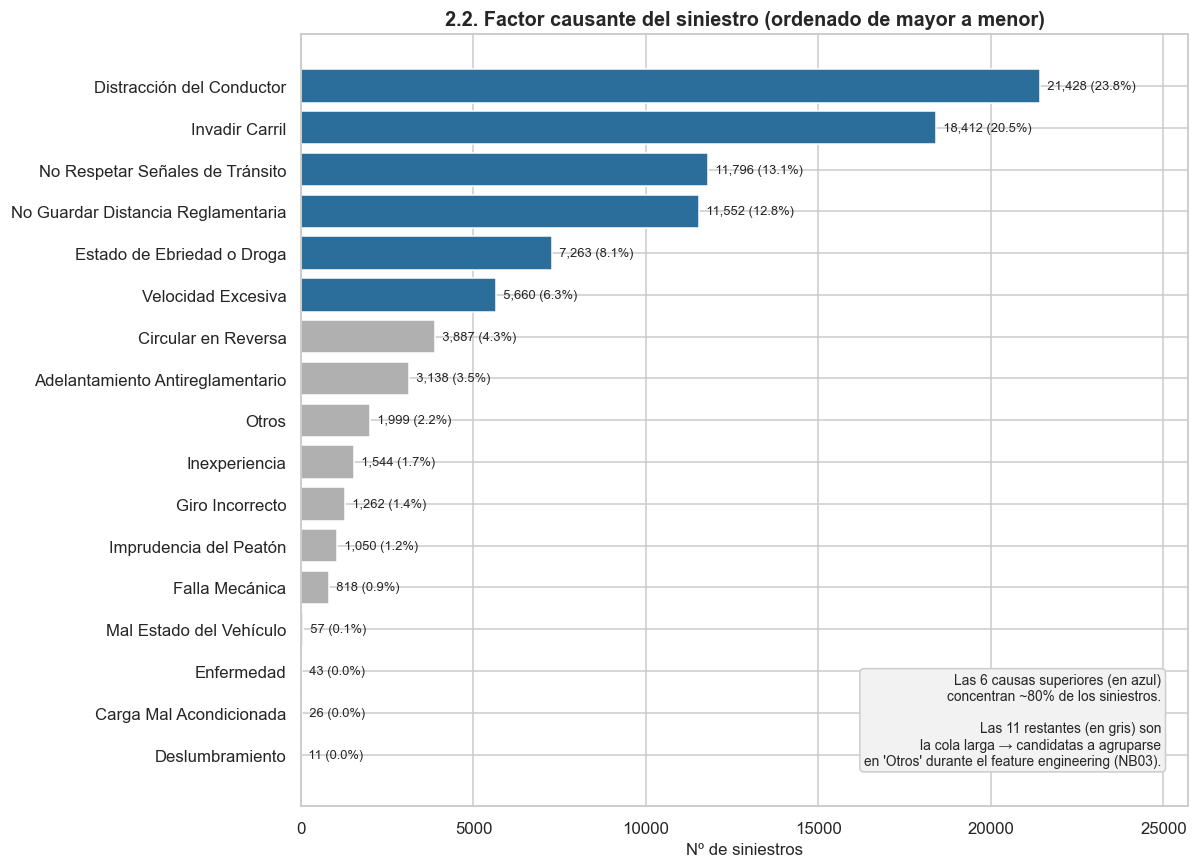

In [23]:
# --- Bloque 2.2: distribución de factor_causante (17 categorías) ---
conteo_fc = siniestros["factor_causante"].value_counts().sort_values(ascending=False)
pct_fc    = conteo_fc / conteo_fc.sum() * 100
acum_fc   = pct_fc.cumsum()

# Nº de causas que concentran el 80%
n_80 = int((acum_fc <= 80).sum()) + 1
causas_80 = list(conteo_fc.index[:n_80])

# Orden ascendente para el barh (mayor arriba)
conteo_plot = conteo_fc[::-1]
pct_plot    = pct_fc[::-1]

fig, ax = plt.subplots(figsize=(11, 8))

# Color diferenciado: causas dentro del 80% en azul fuerte, la cola en gris
colores = [COLOR_PRINCIPAL if cat in causas_80 else COLOR_PARCIAL
           for cat in conteo_plot.index]

ax.barh(conteo_plot.index.astype(str), conteo_plot.values, color=colores)
ax.set_xlabel("Nº de siniestros")
ax.set_title("2.2. Factor causante del siniestro (ordenado de mayor a menor)")

for y, (v, p) in enumerate(zip(conteo_plot.values, pct_plot.values)):
    ax.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)

ax.set_xlim(0, conteo_fc.max() * 1.20)

# Anotación del corte 80% (en el área libre a la derecha)
texto = (f"Las {n_80} causas superiores (en azul)\n"
         f"concentran ~80% de los siniestros.\n\n"
         f"Las {len(conteo_fc) - n_80} restantes (en gris) son\n"
         f"la cola larga → candidatas a agruparse\n"
         f"en 'Otros' durante el feature engineering (NB03).")
ax.text(0.97, 0.05, texto, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="#F2F2F2", edgecolor="#CCCCCC"))

print(f"{n_80} de {len(conteo_fc)} categorías de factor_causante concentran ~80% de los siniestros.")
print("Causas dentro del 80%:", ", ".join(causas_80))

fig.tight_layout()
cfg.save_fig(fig, "nb02_2b_factor_causante")
plt.show()

### 2.3. Severidad univariada

Se examina la distribución del número de **fallecidos** y **lesionados** por siniestro. A
diferencia de los bloques anteriores (variables categóricas), estas son variables de **conteo**,
y su forma es relevante para el modelado posterior.

Se analiza:

- La distribución de `fallecidos` por siniestro (cuántos siniestros tienen 0, 1, 2… fallecidos).
- La distribución de `lesionados` por siniestro.
- La fuerte concentración en cero: la mayoría de los siniestros no registran fallecidos, y algo
  más de la mitad no registran víctimas de ningún tipo (visto en la Sección 1).

Esta concentración en cero y la cola de valores altos son la primera evidencia de que las
variables de conteo del proyecto no se ajustan a una distribución simétrica. La caracterización
formal de esta propiedad —y su consecuencia para la elección entre Poisson y Binomial
Negativa— se retoma en la Sección 8, ya

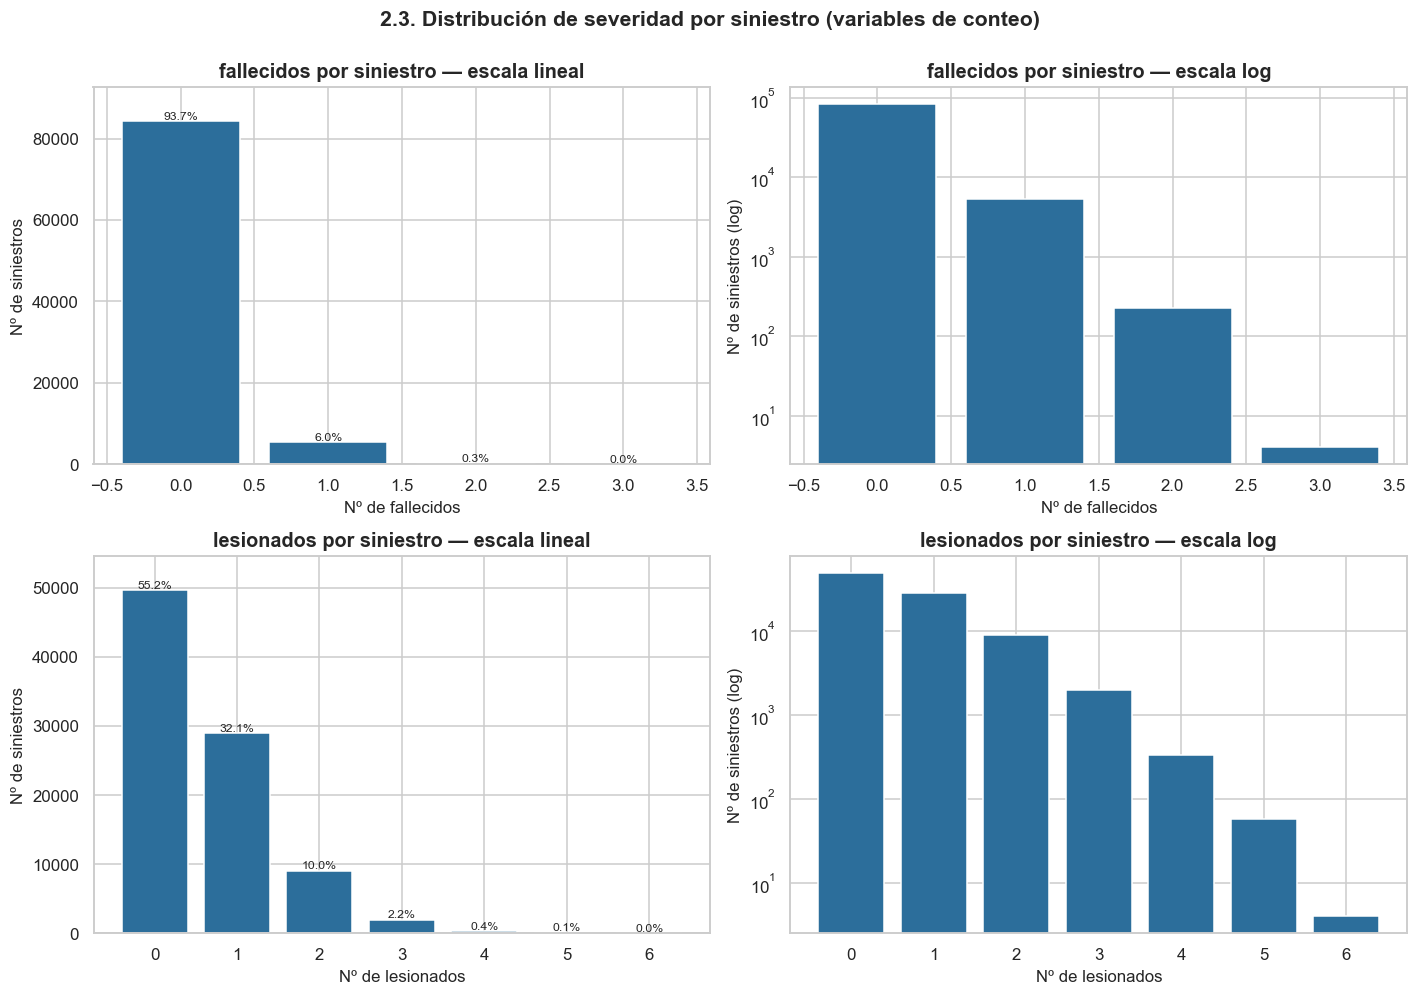

Estadísticos de severidad por siniestro

               count  mean  std  min  25%  50%  75%  max  % en cero
fallecidos 89,946.00  0.07 0.26 0.00 0.00 0.00 0.00 3.00      93.72
lesionados 89,946.00  0.61 0.79 0.00 0.00 0.00 1.00 6.00      55.20


In [24]:
# --- Bloque 2.3: distribución de fallecidos y lesionados por siniestro ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, col in enumerate(["fallecidos", "lesionados"]):
    vc = siniestros[col].value_counts().sort_index()
    pct = vc / vc.sum() * 100

    # --- Columna izquierda: escala lineal (muestra el dominio del cero) ---
    ax_lin = axes[i, 0]
    ax_lin.bar(vc.index.astype(int), vc.values, color=COLOR_PRINCIPAL)
    ax_lin.set_title(f"{col} por siniestro — escala lineal")
    ax_lin.set_xlabel(f"Nº de {col}")
    ax_lin.set_ylabel("Nº de siniestros")
    # Etiqueta de % sobre cada barra
    for x, (v, p) in zip(vc.index, zip(vc.values, pct.values)):
        ax_lin.text(int(x), v, f"{p:.1f}%", ha="center", va="bottom", fontsize=8)
    ax_lin.set_ylim(0, vc.max() * 1.10)

    # --- Columna derecha: escala log (deja ver la cola) ---
    ax_log = axes[i, 1]
    ax_log.bar(vc.index.astype(int), vc.values, color=COLOR_PRINCIPAL)
    ax_log.set_yscale("log")
    ax_log.set_title(f"{col} por siniestro — escala log")
    ax_log.set_xlabel(f"Nº de {col}")
    ax_log.set_ylabel("Nº de siniestros (log)")

fig.suptitle("2.3. Distribución de severidad por siniestro (variables de conteo)",
             fontsize=14, fontweight="bold", y=1.00)
fig.tight_layout()
cfg.save_fig(fig, "nb02_2c_severidad_univariada")
plt.show()

# --- Resumen numérico de las dos variables de conteo ---
print("Estadísticos de severidad por siniestro\n")
resumen_sev = siniestros[["fallecidos", "lesionados"]].describe().T
resumen_sev["% en cero"] = [
    (siniestros["fallecidos"] == 0).mean() * 100,
    (siniestros["lesionados"] == 0).mean() * 100,
]
print(resumen_sev.to_string())

## 3. Patrones temporales

Se analiza cómo se distribuye la siniestralidad en el tiempo, en cuatro escalas: anual,
mensual/estacional, día de la semana y franja horaria. El objetivo es demostrar empíricamente
los patrones temporales documentados y extraer variables de calendario que alimentarán el
*feature engineering* de NB03.

### Convención para el año 2026 (parcial)

Como se anticipó en la Sección 1, 2026 solo cubre ene–jun. Para evitar el artefacto visual de
una "caída" falsa, se aplica el siguiente criterio según el tipo de gráfico:

| Tipo de gráfico | Tratamiento de 2026 |
| --- | --- |
| Totales anuales (barras) | Se incluye, diferenciado (gris + asterisco) |
| Tendencia anual (línea) | Tramo 2026 punteado |
| Comparación seria entre años | Semestre homólogo (ene–jun vs ene–jun) |
| Intra-anual (mes, día, franja) | Se incluye completo, sin marca, normalizado por promedio |

Este criterio preserva el dato real de 2026 sin inducir lecturas equivocadas.

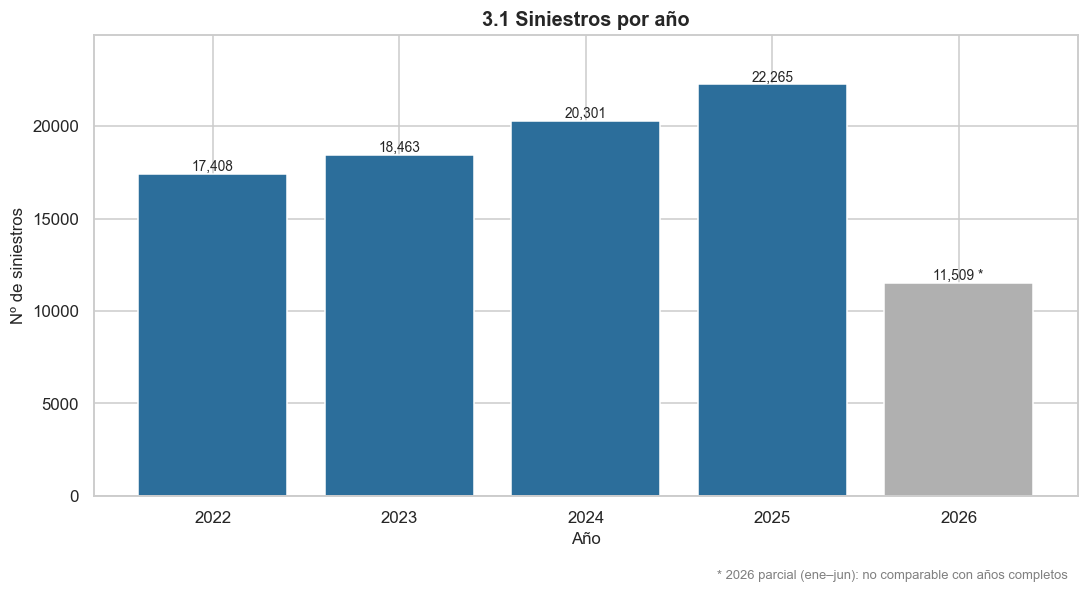

Comparación homóloga — primer semestre (ene–jun) de cada año
 anio  siniestros_ene_jun  var_%
 2022                8307    NaN
 2023                8834   6.34
 2024                9678   9.55
 2025               10612   9.65
 2026               11509   8.45


In [10]:
# --- 3.1 Tendencia anual de siniestros (2026 diferenciado como parcial) ---
serie_anual = (
    siniestros.assign(anio=siniestros["fecha"].dt.year)
              .groupby("anio")
              .agg(siniestros=("id_siniestro", "size"),
                   parcial=("registro_parcial", lambda s: (s == "Si").any()))
              .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.5))

# Barras: años completos en azul, año parcial en gris
colores = [COLOR_PARCIAL if p else COLOR_PRINCIPAL for p in serie_anual["parcial"]]
barras = ax.bar(serie_anual["anio"].astype(str), serie_anual["siniestros"], color=colores)

# Etiqueta de valor sobre cada barra; asterisco en el año parcial
for barra, (_, fila) in zip(barras, serie_anual.iterrows()):
    etiqueta = f"{fila['siniestros']:,.0f}"
    if fila["parcial"]:
        etiqueta += " *"
    ax.text(barra.get_x() + barra.get_width()/2, fila["siniestros"],
            etiqueta, ha="center", va="bottom", fontsize=9)

ax.set_title("3.1 Siniestros por año")
ax.set_xlabel("Año")
ax.set_ylabel("Nº de siniestros")
ax.set_ylim(0, serie_anual["siniestros"].max() * 1.12)

# Nota al pie explicando el asterisco
ax.text(0.99, -0.16, "* 2026 parcial (ene–jun): no comparable con años completos",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="gray")

fig.tight_layout()
cfg.save_fig(fig, "nb02_3_1_tendencia_anual")
plt.show()

# --- Comparación homóloga: semestre ene–jun de cada año ---
sem1 = siniestros[siniestros["fecha"].dt.month <= 6].copy()
sem1_anual = (
    sem1.assign(anio=sem1["fecha"].dt.year)
        .groupby("anio").size()
        .rename("siniestros_ene_jun").reset_index()
)
sem1_anual["var_%"] = sem1_anual["siniestros_ene_jun"].pct_change() * 100

print("Comparación homóloga — primer semestre (ene–jun) de cada año")
print(sem1_anual.to_string(index=False))

### 3.2 Estacionalidad mensual y temporada lluviosa

Se analiza la distribución de siniestros por mes del año, promediando sobre los años disponibles
para no penalizar a diciembre ni sobre-representar los meses de 2026 (ene–jun). Por eso se usa el
**promedio de siniestros por mes**, no la suma.

El interés principal es contrastar la **temporada lluviosa de El Salvador (mayo–octubre)** con la
temporada seca (noviembre–abril). La precipitación deteriora las condiciones de la vía
(visibilidad y adherencia), por lo que se espera una siniestralidad mayor en la temporada
lluviosa. Este contraste es una primera aproximación visual; la relación formal con datos reales
de precipitación (Meteostat) se desarrolla en la Sección 6.

Los picos asociados a **períodos de calendario de pocos días** (semana santa, fiestas
agostinas, fin de año) no se aprecian en esta vista mensual, porque se diluyen al promediar el
mes completo. Esos efectos se examinan más adelante a nivel diario (Sección 3.5), junto con el
efecto de los feriados.

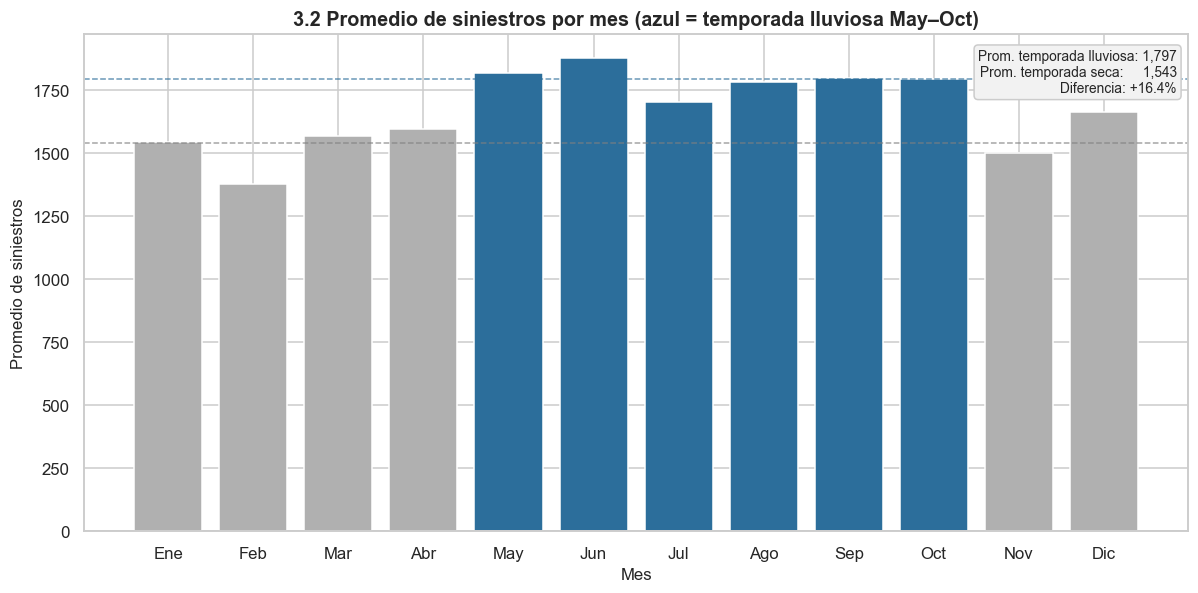

Promedio temporada lluviosa (May–Oct): 1,796.8
Promedio temporada seca   (Nov–Abr): 1,543.1
La temporada lluviosa presenta +16.4% respecto a la seca.


In [16]:
# --- 3.2 Estacionalidad mensual (promedio por mes, no suma) ---
MESES = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
TEMP_LLUVIOSA = set(range(5, 11))  # mayo(5) a octubre(10)

tmp = siniestros.assign(
    anio=siniestros["fecha"].dt.year,
    mes=siniestros["fecha"].dt.month,
)

# Conteo por (año, mes) y luego promedio entre años para cada mes
por_anio_mes = tmp.groupby(["anio", "mes"]).size().rename("n").reset_index()
prom_mes = por_anio_mes.groupby("mes")["n"].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(11, 5.5))
colores = [COLOR_PRINCIPAL if m in TEMP_LLUVIOSA else COLOR_PARCIAL for m in range(1, 13)]
ax.bar(MESES, prom_mes.values, color=colores)

ax.set_title("3.2 Promedio de siniestros por mes (azul = temporada lluviosa May–Oct)")
ax.set_xlabel("Mes")
ax.set_ylabel("Promedio de siniestros")

# Promedios de cada temporada
prom_lluviosa = prom_mes[prom_mes.index.isin(TEMP_LLUVIOSA)].mean()
prom_seca     = prom_mes[~prom_mes.index.isin(TEMP_LLUVIOSA)].mean()
dif_pct = (prom_lluviosa / prom_seca - 1) * 100

ax.axhline(prom_lluviosa, color=COLOR_PRINCIPAL, linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(prom_seca, color="gray", linestyle="--", linewidth=1, alpha=0.7)

texto = (f"Prom. temporada lluviosa: {prom_lluviosa:,.0f}\n"
         f"Prom. temporada seca:     {prom_seca:,.0f}\n"
         f"Diferencia: {dif_pct:+.1f}%")
ax.text(0.99, 0.97, texto, transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="#F2F2F2", edgecolor="#CCCCCC"))

fig.tight_layout()
cfg.save_fig(fig, "nb02_3_2_estacionalidad_mensual")
plt.show()

print(f"Promedio temporada lluviosa (May–Oct): {prom_lluviosa:,.1f}")
print(f"Promedio temporada seca   (Nov–Abr): {prom_seca:,.1f}")
print(f"La temporada lluviosa presenta {dif_pct:+.1f}% respecto a la seca.")

### 3.3 Día de la semana

Se analiza la distribución de siniestros según el día de la semana, usando el **promedio de
siniestros por día** (no la suma) para no sesgar el resultado por la cantidad de veces que cada
día aparece en la ventana temporal.

El patrón esperado en el contexto salvadoreño concentra la mayor siniestralidad hacia el **fin de
semana** (viernes y sábado), asociada a mayor movilidad social y nocturna, con un descenso a
mitad de semana. Este patrón, junto con la franja horaria (Sección 3.4), define variables de
calendario relevantes para el modelado.

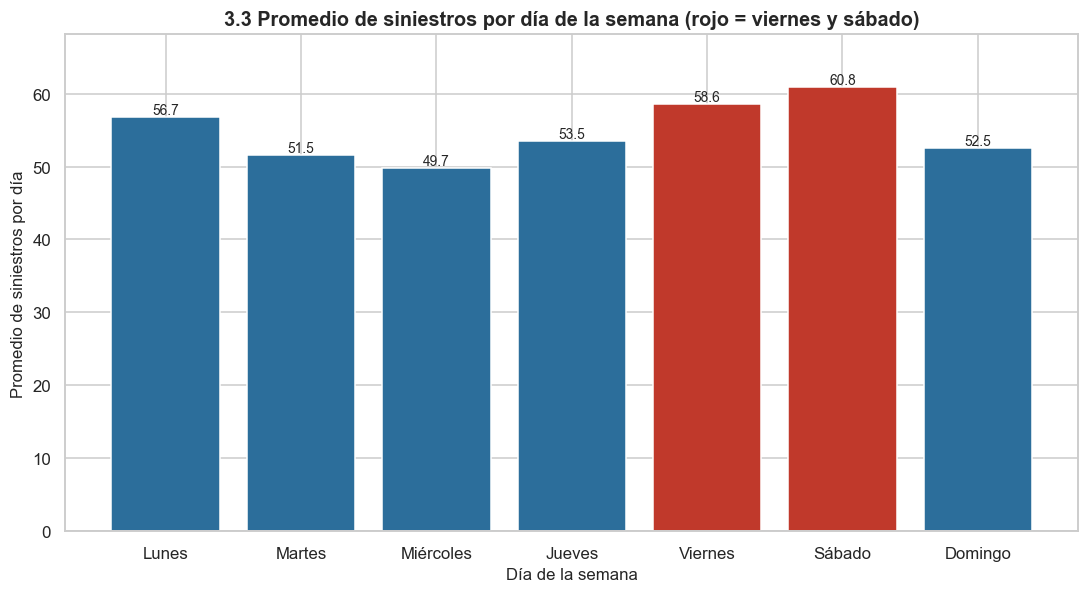

Promedio de siniestros por día (mayor a menor):
  Sábado    : 60.83
  Viernes   : 58.62
  Lunes     : 56.74
  Jueves    : 53.46
  Domingo   : 52.52
  Martes    : 51.53
  Miércoles : 49.74


In [12]:
# --- 3.3 Siniestros por día de la semana (promedio por día) ---
DIAS = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

tmp = siniestros.assign(
    fecha_norm=siniestros["fecha"].dt.normalize(),
    dow=siniestros["fecha"].dt.dayofweek,   # 0=Lunes ... 6=Domingo
)

# Conteo por fecha individual, luego promedio por día de semana
por_fecha = tmp.groupby(["fecha_norm", "dow"]).size().rename("n").reset_index()
prom_dow = por_fecha.groupby("dow")["n"].mean().reindex(range(7))

# Color: resaltar viernes(4) y sábado(5)
colores = [COLOR_ACENTO if d in (4, 5) else COLOR_PRINCIPAL for d in range(7)]

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(DIAS, prom_dow.values, color=colores)

for barra, v in zip(barras, prom_dow.values):
    ax.text(barra.get_x() + barra.get_width()/2, v, f"{v:.1f}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("3.3 Promedio de siniestros por día de la semana (rojo = viernes y sábado)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Promedio de siniestros por día")
ax.set_ylim(0, prom_dow.max() * 1.12)

fig.tight_layout()
cfg.save_fig(fig, "nb02_3_3_dia_semana")
plt.show()

# Orden de mayor a menor para verificar el patrón
orden = prom_dow.sort_values(ascending=False)
print("Promedio de siniestros por día (mayor a menor):")
for d, v in orden.items():
    print(f"  {DIAS[d]:<10}: {v:.2f}")

### 3.4 Franja horaria

Se analiza la distribución de siniestros según la `franja_horaria` del día (madrugada, mañana,
tarde, noche). Como es una variable categórica ya definida en el dato, se usa el promedio de
siniestros por franja para mantener consistencia con la convención de normalización.

El interés es identificar en qué momentos del día se concentra la siniestralidad, un patrón
ligado a los ciclos de movilidad (horas pico laborales, actividad nocturna). La franja horaria
es, junto con el día de la semana, una de las variables de calendario centrales para el
modelado, y más adelante se cruza con la severidad (Sección 5) para distinguir franjas de mayor
letalidad.

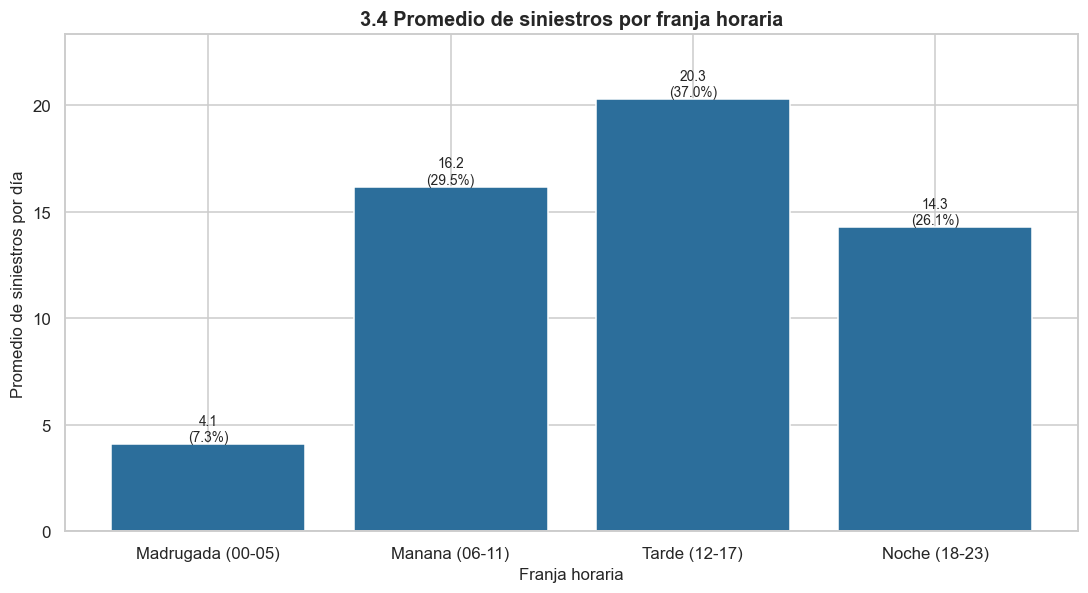

Promedio de siniestros por franja (y % del total):
  Madrugada (00-05) : 4.10   (7.3%)
  Manana (06-11)    : 16.19   (29.5%)
  Tarde (12-17)     : 20.29   (37.0%)
  Noche (18-23)     : 14.28   (26.1%)


In [14]:
# --- 3.4 Siniestros por franja horaria ---
# Etiquetas reales del dato, en orden cronológico del día
ORDEN_FRANJA = ["Madrugada (00-05)", "Manana (06-11)", "Tarde (12-17)", "Noche (18-23)"]

# Conteo por fecha+franja, luego promedio por franja
tmp = siniestros.assign(fecha_norm=siniestros["fecha"].dt.normalize())
por_fecha_franja = tmp.groupby(["fecha_norm", "franja_horaria"]).size().rename("n").reset_index()
prom_franja = por_fecha_franja.groupby("franja_horaria")["n"].mean()

# Reordenar cronológicamente (con las etiquetas reales presentes)
presentes = [f for f in ORDEN_FRANJA if f in prom_franja.index]
prom_franja = prom_franja.reindex(presentes)

# % del total de siniestros por franja (sobre conteo bruto)
pct_franja = siniestros["franja_horaria"].value_counts(normalize=True) * 100
pct_franja = pct_franja.reindex(prom_franja.index)

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(prom_franja.index.astype(str), prom_franja.values, color=COLOR_PRINCIPAL)

for barra, (v, p) in zip(barras, zip(prom_franja.values, pct_franja.values)):
    ax.text(barra.get_x() + barra.get_width()/2, v, f"{v:.1f}\n({p:.1f}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_title("3.4 Promedio de siniestros por franja horaria")
ax.set_xlabel("Franja horaria")
ax.set_ylabel("Promedio de siniestros por día")
ax.set_ylim(0, prom_franja.max() * 1.15)

fig.tight_layout()
cfg.save_fig(fig, "nb02_3_4_franja_horaria")
plt.show()

print("Promedio de siniestros por franja (y % del total):")
for f in prom_franja.index:
    print(f"  {str(f):<18}: {prom_franja[f]:.2f}   ({pct_franja[f]:.1f}%)")

### 3.5 Feriados y períodos de calendario

Las escalas anteriores (mes, día de semana, franja) promedian sobre períodos largos, por lo que
diluyen efectos de pocos días. Esta sección los recupera con un análisis a **nivel diario**,
donde sí se observan los picos asociados al calendario.

Se examinan dos efectos:

- **Efecto feriado**: se compara el promedio de siniestros de los días marcados como feriado en
  el calendario oficial frente a los días no feriados. Se espera una siniestralidad elevada en
  feriados por mayor movilidad recreativa.
- **Períodos de calendario de alta movilidad**: se observa el perfil diario a lo largo del año,
  destacando por igual tres períodos conocidos de movilidad atípica —semana santa, fiestas
  agostinas y fin de año— para ver, sin sesgo de selección, cuáles efectivamente elevan la
  siniestralidad y cuáles no. Estos efectos quedan ocultos en la vista mensual (Sección 3.2) al
  promediarse con el resto del mes.

Dos consideraciones metodológicas:

- **Feriados locales**: el calendario incluye feriados de alcance nacional y local (p. ej. las
  fiestas patronales de un distrito específico). Para este análisis exploratorio se usa el efecto
  agregado; la aplicación de feriados locales al distrito correspondiente se trata con precisión
  en el *feature engineering* de NB03.
- **Semana santa** es de fecha variable cada año; al promediar por día-del-año su pico tiende a
  suavizarse, mientras que las fiestas agostinas (fechas fijas 1–6 ago) se concentran. Esta
  diferencia de alineación se tiene en cuenta al interpretar la gráfica.

/var/folders/vr/117fzs5j7g36v1wtxyh0544w0000gp/T/ipykernel_19679/2731606179.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax0.boxplot([data_no, data_si], labels=["No feriado", "Feriado"],


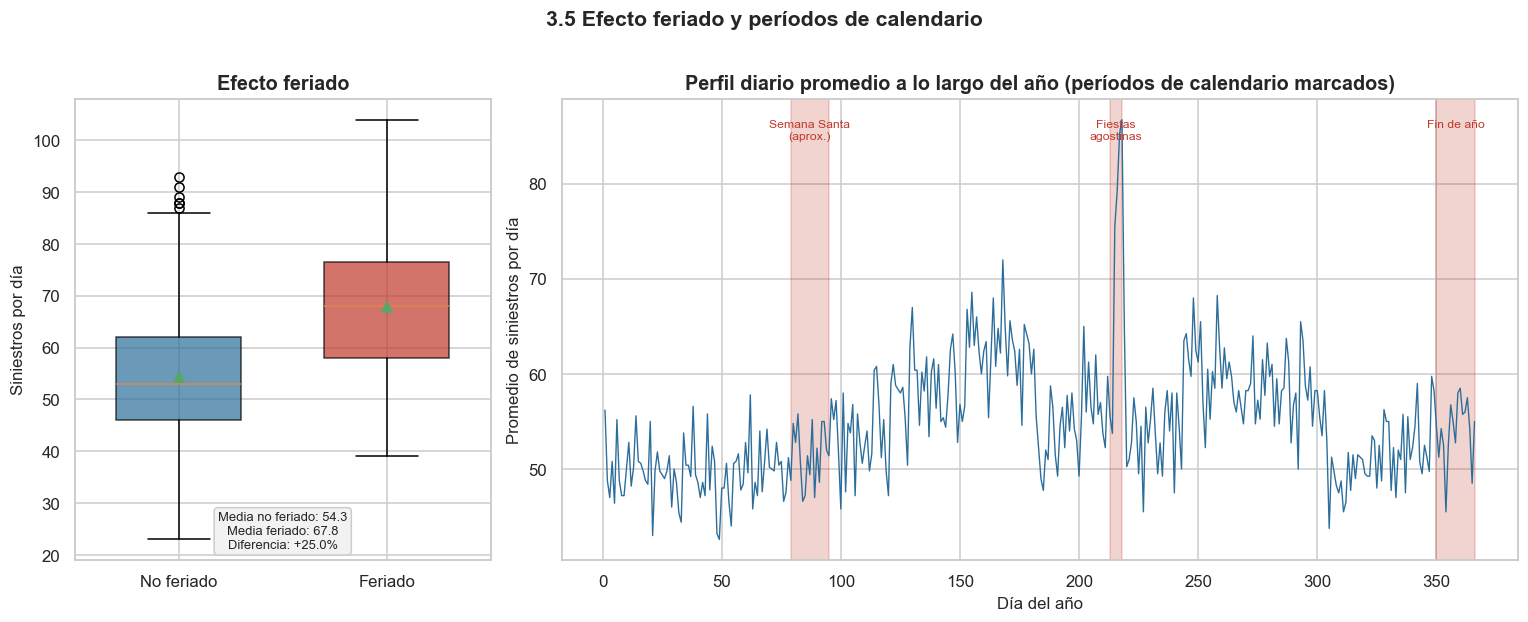

Efecto feriado (agregado): +25.0%

Promedio de siniestros por día, por período de calendario:
  Semana Santa (aprox.) : 51.4  (-6.3% vs promedio anual)
  Fiestas agostinas     : 72.7  (+32.4% vs promedio anual)
  Fin de año            : 54.0  (-1.5% vs promedio anual)
  Promedio anual        : 54.9


In [17]:
# --- 3.5 Efecto feriado y períodos de calendario (nivel diario) ---

# Conteo de siniestros por fecha
diario = (siniestros.assign(fecha_norm=siniestros["fecha"].dt.normalize())
                    .groupby("fecha_norm").size().rename("n").reset_index())

# Marcar feriados usando el calendario oficial
fechas_feriado = set(pd.to_datetime(feriados["fecha"]).dt.normalize())
diario["es_feriado"] = diario["fecha_norm"].isin(fechas_feriado)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"width_ratios": [1, 2.3]})

# --- Panel 1: efecto feriado ---
ax0 = axes[0]
data_no = diario.loc[~diario["es_feriado"], "n"]
data_si = diario.loc[diario["es_feriado"], "n"]
bp = ax0.boxplot([data_no, data_si], labels=["No feriado", "Feriado"],
                 patch_artist=True, showmeans=True, widths=0.6)
for parche, color in zip(bp["boxes"], [COLOR_PRINCIPAL, COLOR_ACENTO]):
    parche.set_facecolor(color)
    parche.set_alpha(0.7)
ax0.set_title("Efecto feriado")
ax0.set_ylabel("Siniestros por día")

media_no, media_si = data_no.mean(), data_si.mean()
dif_feriado = (media_si / media_no - 1) * 100
ax0.text(0.5, 0.02,
         f"Media no feriado: {media_no:.1f}\nMedia feriado: {media_si:.1f}\n"
         f"Diferencia: {dif_feriado:+.1f}%",
         transform=ax0.transAxes, ha="center", va="bottom", fontsize=8.5,
         bbox=dict(boxstyle="round", facecolor="#F2F2F2", edgecolor="#CCCCCC"))

# --- Panel 2: perfil diario con TRES períodos marcados por igual ---
ax1 = axes[1]
diario["doy"] = diario["fecha_norm"].dt.dayofyear
perfil_doy = diario.groupby("doy")["n"].mean()
ax1.plot(perfil_doy.index, perfil_doy.values, color=COLOR_PRINCIPAL, linewidth=0.9)

# Períodos de calendario (día-del-año aproximado; semana santa es variable, se usa rango típico)
periodos = {
    "Semana Santa\n(aprox.)": (79, 95),    # ~20 mar – 5 abr (variable cada año)
    "Fiestas\nagostinas":     (213, 218),  # 1–6 ago
    "Fin de año":             (350, 366),  # ~16–31 dic
}

y_top = perfil_doy.max()
for nombre, (ini, fin) in periodos.items():
    ax1.axvspan(ini, fin, color=COLOR_ACENTO, alpha=0.22)
    ax1.text((ini + fin) / 2, y_top, nombre, ha="center", va="top",
             fontsize=8, color=COLOR_ACENTO)

ax1.set_title("Perfil diario promedio a lo largo del año (períodos de calendario marcados)")
ax1.set_xlabel("Día del año")
ax1.set_ylabel("Promedio de siniestros por día")

fig.suptitle("3.5 Efecto feriado y períodos de calendario",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_3_5_feriados_calendario")
plt.show()

# --- Comparación objetiva: promedio dentro de cada período vs promedio anual ---
print(f"Efecto feriado (agregado): {dif_feriado:+.1f}%\n")
print("Promedio de siniestros por día, por período de calendario:")
base = perfil_doy.mean()
for nombre, (ini, fin) in periodos.items():
    mask = (perfil_doy.index >= ini) & (perfil_doy.index <= fin)
    prom_periodo = perfil_doy[mask].mean()
    dif = (prom_periodo / base - 1) * 100
    etiqueta = nombre.replace("\n", " ")
    print(f"  {etiqueta:<22}: {prom_periodo:.1f}  ({dif:+.1f}% vs promedio anual)")
print(f"  {'Promedio anual':<22}: {base:.1f}")

### 3.6 Síntesis de patrones temporales

Los patrones temporales observados en el dato son consistentes y se resumen así:

- **Anual**: crecimiento sostenido de la siniestralidad 2022–2025; el primer semestre de 2026
  mantiene la tendencia (+8.4% homólogo vs 2025).
- **Estacional**: la temporada lluviosa (May–Oct) presenta ~16% más siniestros que la seca,
  consistente con el efecto de la precipitación sobre las condiciones de la vía.
- **Día de la semana**: pico en viernes y sábado (Sáb el más alto), valle a mitad de semana.
- **Franja horaria**: concentración en la tarde (12–17 h, ~37%), seguida de la mañana; mínimo en
  la madrugada.
- **Calendario**: los días feriados presentan +25% de siniestros frente a los no feriados. Entre
  los períodos de calendario, solo las **fiestas agostinas** muestran un pico marcado (+32% vs
  promedio anual); semana santa y fin de año no destacan en la vista por día-del-año.

Variables de calendario derivadas de estos patrones (mes, temporada lluviosa, fin de semana,
franja horaria, feriado, período agostino) alimentarán el *feature engineering* de NB03.

## 4. Patrones espaciales

Se analiza la distribución geográfica de la siniestralidad en tres niveles de agregación
—departamento, distrito y coordenadas GPS— con dos lecturas complementarias:

- **Conteo bruto**: dónde ocurren más siniestros en términos absolutos.
- **Tasa por exposición (per cápita)**: dónde ocurren más siniestros *en relación con la
  población*, usando el Censo 2024 como denominador.

Esta distinción es central para el proyecto. El conteo bruto está dominado por las zonas de mayor
población y parque vehicular (el Área Metropolitana de San Salvador), lo cual es esperable pero
poco informativo por sí solo: refleja *exposición*, no necesariamente *riesgo*. Normalizar por
población permite distinguir zonas donde la siniestralidad es alta más allá de lo que su tamaño
explicaría.

El análisis espacial se organiza así:

- **4.1** — ranking por departamento (conteo bruto) y concentración del AMSS.
- **4.2** — ranking por distrito y contraste conteo bruto vs tasa per cápita.
- **4.3** — distribución geográfica con coordenadas GPS (mapa de puntos / densidad).

Nota sobre el *join* con población: el cruce con el Censo 2024 se realiza aquí de forma **local y
exploratoria**, con el único fin de visualizar la tasa per cápita. La grilla formal y
reproducible se construye en NB03.

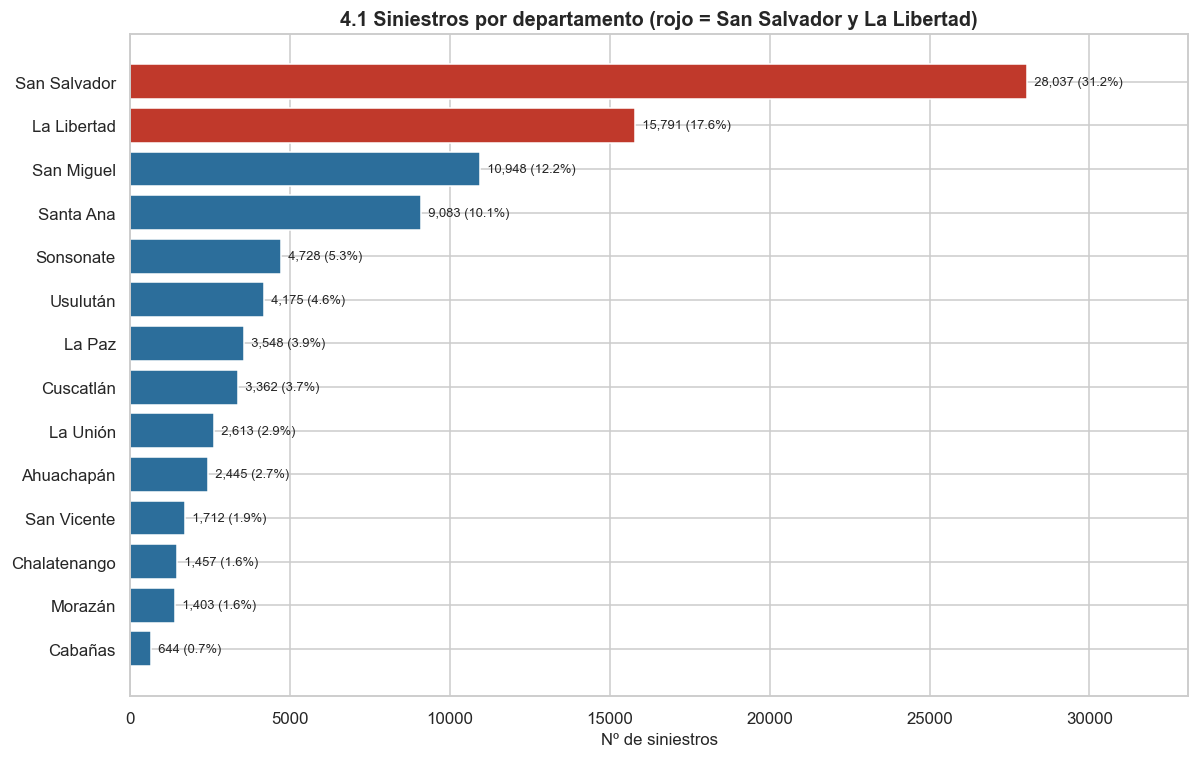

Ranking de departamentos por siniestros (conteo bruto):

  San Salvador        :  28,037  (31.2%)
  La Libertad         :  15,791  (17.6%)
  San Miguel          :  10,948  (12.2%)
  Santa Ana           :   9,083  (10.1%)
  Sonsonate           :   4,728  (5.3%)
  Usulután            :   4,175  (4.6%)
  La Paz              :   3,548  (3.9%)
  Cuscatlán           :   3,362  (3.7%)
  La Unión            :   2,613  (2.9%)
  Ahuachapán          :   2,445  (2.7%)
  San Vicente         :   1,712  (1.9%)
  Chalatenango        :   1,457  (1.6%)
  Morazán             :   1,403  (1.6%)
  Cabañas             :     644  (0.7%)

San Salvador + La Libertad concentran el 48.7% de los siniestros.


In [18]:
# --- 4.1 Ranking de siniestros por departamento (conteo bruto) ---

# Distritos que conforman el Área Metropolitana de San Salvador (AMSS)
# (se usa para cuantificar la concentración metropolitana)
DEPTOS_AMSS = {"San Salvador", "La Libertad"}  # aproximación departamental para esta vista

conteo_depto = (siniestros.groupby("departamento").size()
                          .sort_values(ascending=False)
                          .rename("siniestros"))
pct_depto = conteo_depto / conteo_depto.sum() * 100

fig, ax = plt.subplots(figsize=(11, 7))
conteo_plot = conteo_depto[::-1]
pct_plot = pct_depto[::-1]

# Resaltar San Salvador y La Libertad
colores = [COLOR_ACENTO if d in DEPTOS_AMSS else COLOR_PRINCIPAL for d in conteo_plot.index]
ax.barh(conteo_plot.index.astype(str), conteo_plot.values, color=colores)

for y, (v, p) in enumerate(zip(conteo_plot.values, pct_plot.values)):
    ax.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)

ax.set_title("4.1 Siniestros por departamento (rojo = San Salvador y La Libertad)")
ax.set_xlabel("Nº de siniestros")
ax.set_xlim(0, conteo_depto.max() * 1.18)

fig.tight_layout()
cfg.save_fig(fig, "nb02_4_1_ranking_departamento")
plt.show()

# Concentración de los departamentos del AMSS
pct_amss = pct_depto[pct_depto.index.isin(DEPTOS_AMSS)].sum()
print("Ranking de departamentos por siniestros (conteo bruto):\n")
for d in conteo_depto.index:
    print(f"  {d:<20}: {conteo_depto[d]:>7,}  ({pct_depto[d]:.1f}%)")
print(f"\nSan Salvador + La Libertad concentran el {pct_amss:.1f}% de los siniestros.")

### 4.2 Ranking por distrito: conteo bruto vs tasa per cápita

Se desciende al nivel de **distrito** (la unidad territorial fina tras la reforma de 2023) y se
comparan dos lecturas:

- **Conteo bruto**: los distritos con más siniestros en términos absolutos. Se espera que estén
  dominados por los distritos más poblados del AMSS.
- **Tasa por cada 10 000 habitantes**: los siniestros de cada distrito normalizados por su
  población (Censo 2024). Esta lectura revela dónde la siniestralidad es alta *en relación con el
  tamaño del distrito*, que es una aproximación más cercana al riesgo que el conteo bruto.

El contraste entre ambos rankings es el argumento central de esta sección: si los dos coincidieran,
el conteo bruto bastaría; si difieren, se demuestra que **normalizar por exposición aporta
información que el conteo bruto oculta**. Esto fundamenta el uso de población como variable de
exposición en el modelado (NB03) y contextualiza el clustering espacial (ST-DBSCAN) de etapas
posteriores.

El *join* con el Censo 2024 se hace aquí de forma local y exploratoria, únicamente para
visualizar la tasa.

AVISO: 23 distritos sin población asignada en el join (se excluyen de la tasa).


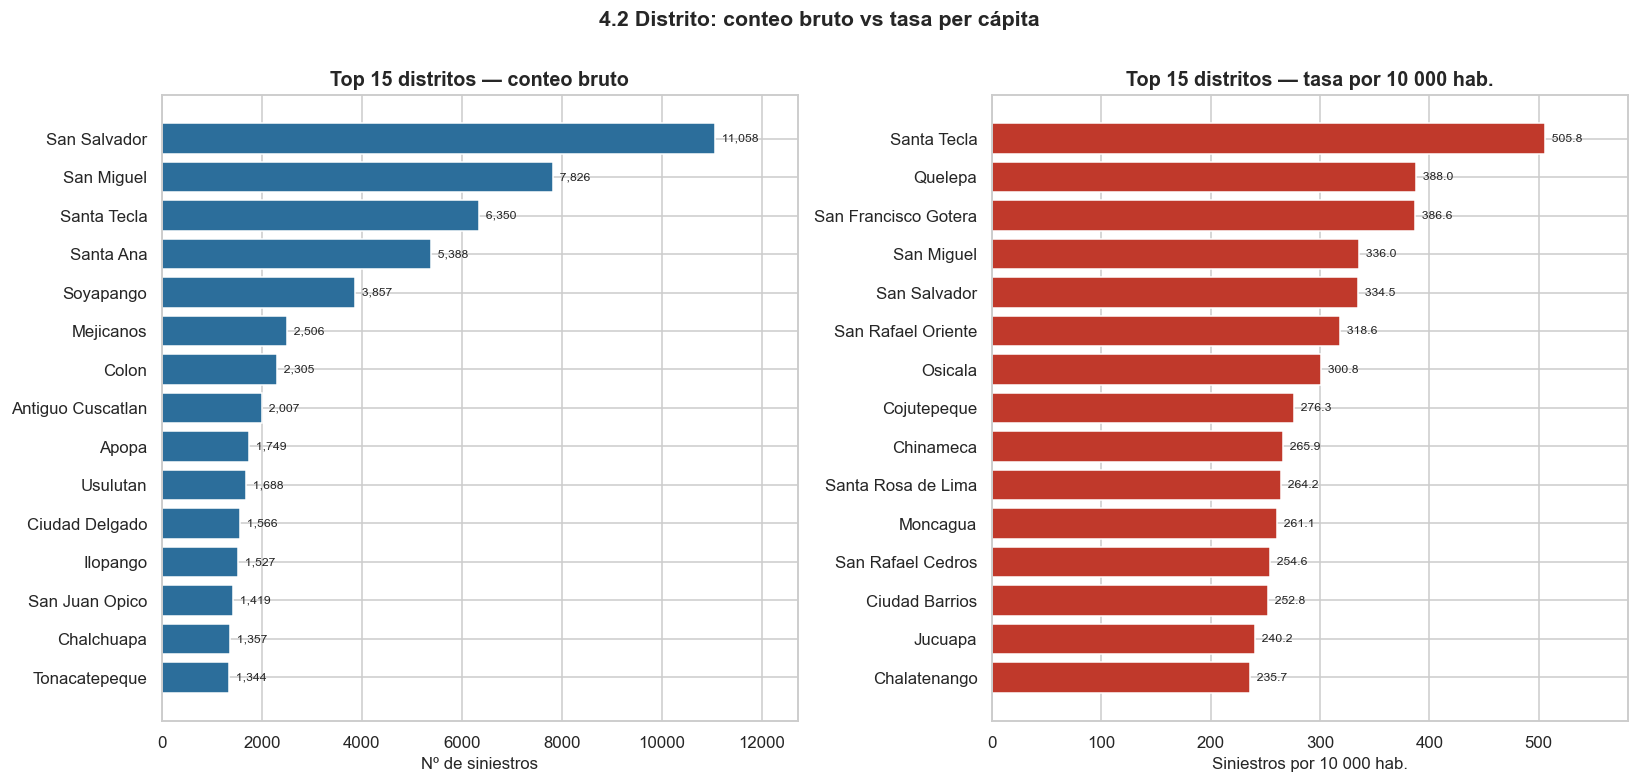


Distritos en ambos Top 15 (bruto y tasa): 3 de 15
Coinciden: San Miguel, San Salvador, Santa Tecla

Top 5 por tasa per cápita (10k hab.):
  Santa Tecla              : 505.8  (6,350 sin. / 125,532 hab.)
  Quelepa                  : 388.0  (274 sin. / 7,062 hab.)
  San Francisco Gotera     : 386.6  (786 sin. / 20,330 hab.)
  San Miguel               : 336.0  (7,826 sin. / 232,887 hab.)
  San Salvador             : 334.5  (11,058 sin. / 330,543 hab.)


In [19]:
# --- 4.2 Ranking por distrito: conteo bruto vs tasa per cápita ---

# Conteo de siniestros por distrito
conteo_dist = siniestros.groupby("distrito").size().rename("siniestros").reset_index()

# Join local (exploratorio) con población del Censo 2024
# Se asume que 'censo' tiene columnas 'distrito' y 'poblacion'.
pob = censo[["distrito", "poblacion"]].copy()
dist = conteo_dist.merge(pob, on="distrito", how="left")

# Reportar distritos sin match de población (si los hubiera)
sin_pob = dist["poblacion"].isna().sum()
if sin_pob:
    print(f"AVISO: {sin_pob} distritos sin población asignada en el join (se excluyen de la tasa).")

# Tasa por cada 10 000 habitantes
dist["tasa_10k"] = dist["siniestros"] / dist["poblacion"] * 10_000

# --- Top 15 por conteo bruto ---
top_bruto = dist.sort_values("siniestros", ascending=False).head(15)

# --- Top 15 por tasa per cápita (solo distritos con población válida) ---
top_tasa = (dist.dropna(subset=["poblacion"])
                .sort_values("tasa_10k", ascending=False)
                .head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel izquierdo: conteo bruto
ax0 = axes[0]
d0 = top_bruto[::-1]
ax0.barh(d0["distrito"].astype(str), d0["siniestros"], color=COLOR_PRINCIPAL)
for y, v in enumerate(d0["siniestros"].values):
    ax0.text(v, y, f"  {v:,.0f}", va="center", fontsize=8)
ax0.set_title("Top 15 distritos — conteo bruto")
ax0.set_xlabel("Nº de siniestros")
ax0.set_xlim(0, d0["siniestros"].max() * 1.15)

# Panel derecho: tasa per cápita
ax1 = axes[1]
d1 = top_tasa[::-1]
ax1.barh(d1["distrito"].astype(str), d1["tasa_10k"], color=COLOR_ACENTO)
for y, v in enumerate(d1["tasa_10k"].values):
    ax1.text(v, y, f"  {v:.1f}", va="center", fontsize=8)
ax1.set_title("Top 15 distritos — tasa por 10 000 hab.")
ax1.set_xlabel("Siniestros por 10 000 hab.")
ax1.set_xlim(0, d1["tasa_10k"].max() * 1.15)

fig.suptitle("4.2 Distrito: conteo bruto vs tasa per cápita",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
cfg.save_fig(fig, "nb02_4_2_distrito_bruto_vs_tasa")
plt.show()

# --- Cuántos distritos del top bruto aparecen también en el top tasa ---
set_bruto = set(top_bruto["distrito"])
set_tasa = set(top_tasa["distrito"])
coinciden = set_bruto & set_tasa
print(f"\nDistritos en ambos Top 15 (bruto y tasa): {len(coinciden)} de 15")
print("Coinciden:", ", ".join(sorted(coinciden)) if coinciden else "ninguno")
print("\nTop 5 por tasa per cápita (10k hab.):")
for _, r in top_tasa.head(5).iterrows():
    print(f"  {r['distrito']:<25}: {r['tasa_10k']:.1f}  ({r['siniestros']:,.0f} sin. / {r['poblacion']:,.0f} hab.)")

### 4.3 Distribución geográfica (coordenadas GPS)

Finalmente se representa la siniestralidad sobre el espacio físico usando las coordenadas GPS de
cada siniestro. Esta vista cumple dos propósitos:

- Confirmar que la distribución espacial de los eventos es geográficamente coherente (los puntos
  caen dentro del territorio nacional y se concentran en los núcleos urbanos).
- Ofrecer la primera representación de **densidad espacial**, que es la materia prima del
  clustering espacio-temporal (ST-DBSCAN) de las etapas posteriores. Las zonas de alta densidad
  de puntos anticipan los conglomerados que ese algoritmo formalizará.

Se presentan dos paneles: un mapa de dispersión de los siniestros (con transparencia para revelar
la densidad por acumulación) y un mapa de densidad (hexbin) que agrega los puntos en celdas para
una lectura más limpia de las zonas calientes.

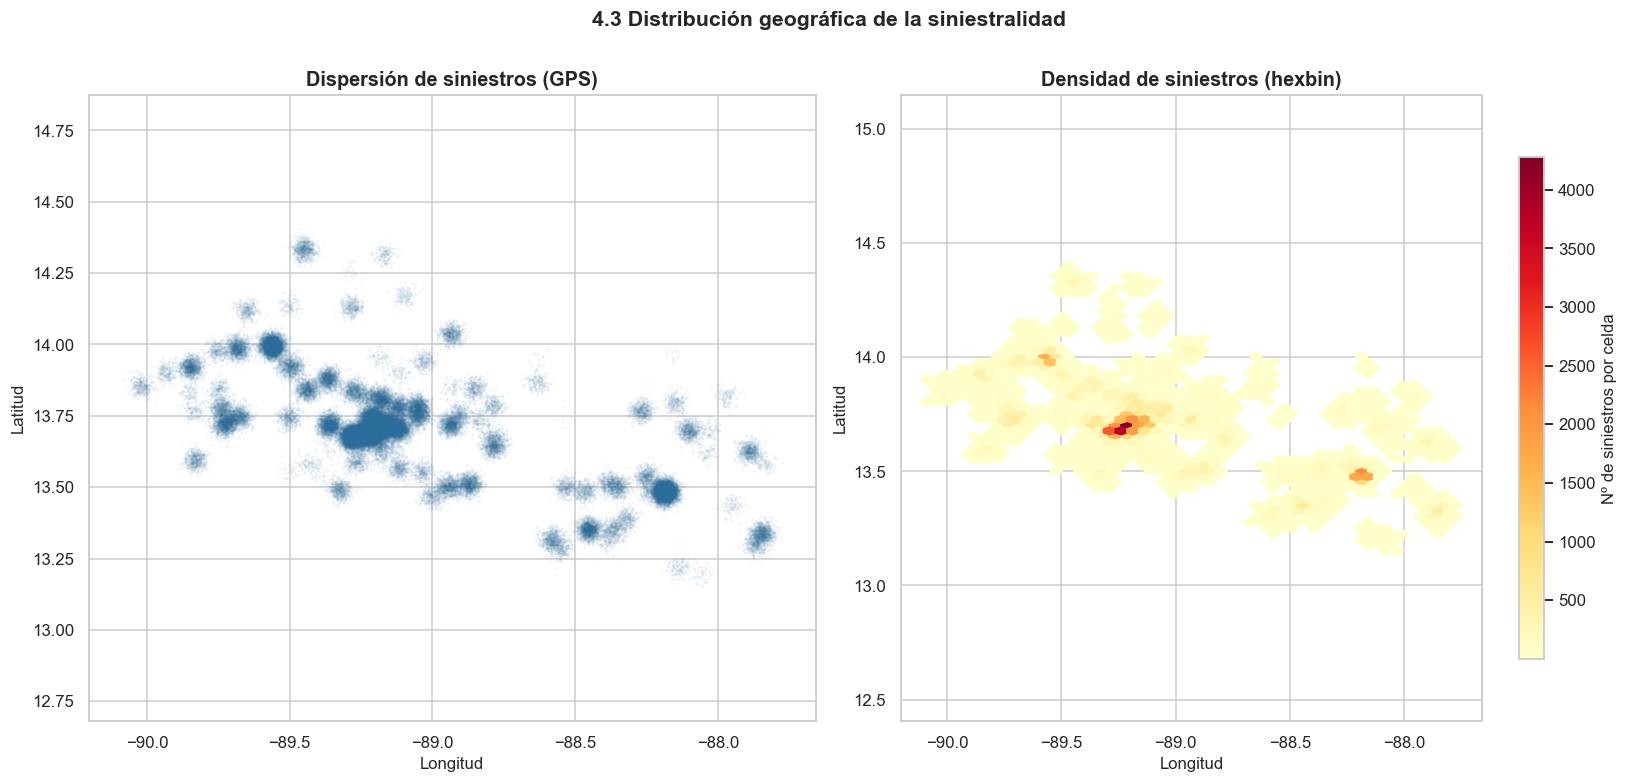

Rango de coordenadas:
  Latitud : 13.151  a  14.404
  Longitud: -90.088  a  -87.772
  (El Salvador: lat ~13.1–14.5, lon ~-90.1 a -87.7)


In [20]:
# --- 4.3 Distribución geográfica de siniestros (GPS) ---
# Se asume que siniestros tiene columnas 'latitud' y 'longitud'.

lat = siniestros["latitud"]
lon = siniestros["longitud"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel izquierdo: dispersión con transparencia (densidad por acumulación)
ax0 = axes[0]
ax0.scatter(lon, lat, s=3, alpha=0.06, color=COLOR_PRINCIPAL, edgecolors="none")
ax0.set_title("Dispersión de siniestros (GPS)")
ax0.set_xlabel("Longitud")
ax0.set_ylabel("Latitud")
ax0.set_aspect("equal", adjustable="datalim")

# Panel derecho: densidad hexbin
ax1 = axes[1]
hb = ax1.hexbin(lon, lat, gridsize=45, cmap="YlOrRd", mincnt=1)
ax1.set_title("Densidad de siniestros (hexbin)")
ax1.set_xlabel("Longitud")
ax1.set_ylabel("Latitud")
ax1.set_aspect("equal", adjustable="datalim")
cb = fig.colorbar(hb, ax=ax1, shrink=0.8)
cb.set_label("Nº de siniestros por celda")

fig.suptitle("4.3 Distribución geográfica de la siniestralidad",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
cfg.save_fig(fig, "nb02_4_3_mapa_gps")
plt.show()

# Rango de coordenadas (verificación de que caen en El Salvador)
print("Rango de coordenadas:")
print(f"  Latitud : {lat.min():.3f}  a  {lat.max():.3f}")
print(f"  Longitud: {lon.min():.3f}  a  {lon.max():.3f}")
print(f"  (El Salvador: lat ~13.1–14.5, lon ~-90.1 a -87.7)")

### 4.4 Síntesis de patrones espaciales

**Qué demostró el análisis**

- El **conteo bruto** está dominado por los distritos más poblados del AMSS y las cabeceras
  departamentales (San Salvador, San Miguel, Santa Tecla, Santa Ana, Soyapango). A nivel
  departamental, San Salvador y La Libertad concentran el 48.7% de los siniestros.
- La **tasa por exposición (per cápita)** reordena el panorama por completo: solo 3 de los 15
  distritos del ranking bruto permanecen en el ranking por tasa. Aparecen distritos —varios del
  oriente del país— con siniestralidad alta en relación con su población, que el conteo bruto
  ocultaba.
- El mapa de densidad (hexbin) confirma tres zonas calientes principales: el AMSS (la de mayor
  intensidad), San Miguel al oriente y Santa Ana al occidente. Las coordenadas caen íntegramente
  dentro del territorio nacional.

**Conclusión central**: normalizar por exposición aporta información que el conteo bruto no
contiene. Conteo bruto y riesgo relativo son medidas distintas y ambas son necesarias.

**Limitaciones del denominador (población residente)**

La tasa per cápita, calculada con población del Censo 2024, tiene dos limitaciones que obligan a
interpretarla con cautela:

- **Zonas de paso**: distritos con alto tránsito no residente (p. ej. Santa Tecla, corredor
  comercial y de conexión hacia La Libertad) ven su exposición real subestimada por la población
  residente, lo que **infla artificialmente** su tasa. La población que reside no equivale a la
  población que circula.
- **Volatilidad en distritos pequeños**: en distritos de baja población (p. ej. Quelepa, ~7 000
  hab.), la tasa se vuelve inestable, ya que pocos siniestros producen valores muy altos por el
  denominador reducido.

**Sobre los conglomerados del oriente**: varios distritos que destacan en la tasa (San Francisco
Gotera, Osícala, Chinameca, Moncagua, San Rafael Oriente) se ubican en la región de
San Miguel–Morazán, geográficamente compatible con corredores viales de la zona como la Ruta
Militar (CA-7). No obstante, dado que la capa de eventos es sintética calibrada, este patrón se
plantea como **hipótesis geográfica a validar con datos reales**, no como una afirmación sobre la
peligrosidad observada de esas vías.

**Decisiones que se trasladan a NB03**

- Construir un indicador de exposición **más completo que la población residente**, incorporando
  el parque vehicular por distrito (y, donde sea posible, un factor de tránsito), en línea con la
  exposición usada en la calibración del dataset.
- **Filtrar o señalar** los distritos de población muy baja para evitar tasas volátiles, mediante
  un umbral mínimo de población o un suavizado.
- Tratar la tasa per cápita como **una señal entre varias** (no como medida única de riesgo) al
  definir el objetivo de clasificación de nivel de riesgo.

## 5. Víctimas y severidad

Esta sección analiza la capa de **víctimas** (`victimas`, 60 402 personas enlazadas a los
siniestros por `id_siniestro`), con foco en quién resulta afectado y con qué gravedad.

El interés principal es la **vulnerabilidad diferencial por tipo de usuario de la vía**: en la
siniestralidad vial, los usuarios no protegidos (peatones, motociclistas, ciclistas) suelen estar
sobre-representados en los desenlaces graves respecto a su participación en el total de víctimas.
Distinguir frecuencia de gravedad es clave para caracterizar el riesgo real.

El análisis se organiza así:

- **5.1** — composición de víctimas por tipo de usuario y condición (ileso / lesionado /
  fallecido).
- **5.2** — vulnerabilidad en desenlaces fatales: perfil de los fallecidos por tipo de usuario.
- **5.3** — severidad por rango etario.

Como se vio en la Sección 1, alrededor del 52 % de los siniestros no tienen víctimas (solo daños
materiales). Esta sección trabaja, por definición, sobre el universo de siniestros **con**
víctimas.

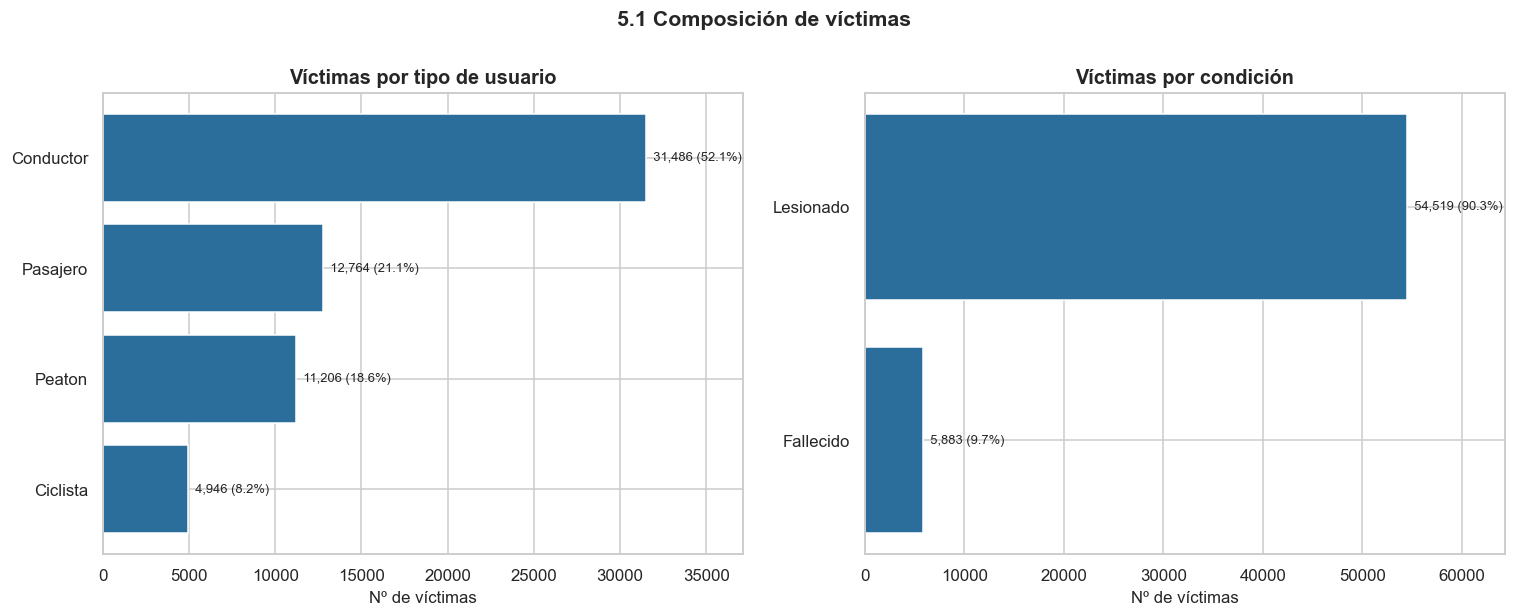

Víctimas por tipo de usuario:
  Conductor      :  31,486  (52.1%)
  Pasajero       :  12,764  (21.1%)
  Peaton         :  11,206  (18.6%)
  Ciclista       :   4,946  (8.2%)

Víctimas por condición:
  Lesionado      :  54,519  (90.3%)
  Fallecido      :   5,883  (9.7%)


In [21]:
# --- 5.1 Composición de víctimas por tipo de usuario y condición ---

# Distribución por tipo de usuario
comp_usuario = victimas["tipo_usuario"].value_counts()
pct_usuario = comp_usuario / comp_usuario.sum() * 100

# Distribución por condición (ileso / lesionado / fallecido)
comp_cond = victimas["condicion"].value_counts()
pct_cond = comp_cond / comp_cond.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel izquierdo: tipo de usuario
ax0 = axes[0]
d0 = comp_usuario[::-1]
p0 = pct_usuario[::-1]
ax0.barh(d0.index.astype(str), d0.values, color=COLOR_PRINCIPAL)
for y, (v, p) in enumerate(zip(d0.values, p0.values)):
    ax0.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)
ax0.set_title("Víctimas por tipo de usuario")
ax0.set_xlabel("Nº de víctimas")
ax0.set_xlim(0, comp_usuario.max() * 1.18)

# Panel derecho: condición
ax1 = axes[1]
d1 = comp_cond[::-1]
p1 = pct_cond[::-1]
ax1.barh(d1.index.astype(str), d1.values, color=COLOR_PRINCIPAL)
for y, (v, p) in enumerate(zip(d1.values, p1.values)):
    ax1.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)
ax1.set_title("Víctimas por condición")
ax1.set_xlabel("Nº de víctimas")
ax1.set_xlim(0, comp_cond.max() * 1.18)

fig.suptitle("5.1 Composición de víctimas", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
cfg.save_fig(fig, "nb02_5_1_composicion_victimas")
plt.show()

print("Víctimas por tipo de usuario:")
for u in comp_usuario.index:
    print(f"  {str(u):<15}: {comp_usuario[u]:>7,}  ({pct_usuario[u]:.1f}%)")
print("\nVíctimas por condición:")
for c in comp_cond.index:
    print(f"  {str(c):<15}: {comp_cond[c]:>7,}  ({pct_cond[c]:.1f}%)")

## 5. Víctimas y severidad

Esta sección analiza la capa de **víctimas** (`victimas`, 60 402 personas enlazadas a los
siniestros por `id_siniestro`), con foco en quién resulta afectado y con qué gravedad.

El interés principal es la **vulnerabilidad diferencial por tipo de usuario de la vía**: en la
siniestralidad vial, los usuarios no protegidos (peatones, motociclistas, ciclistas) suelen estar
sobre-representados en los desenlaces graves respecto a su participación en el total de víctimas.
Distinguir frecuencia de gravedad es clave para caracterizar el riesgo real.

El análisis se organiza así:

- **5.1** — composición de víctimas por tipo de usuario y condición (ileso / lesionado /
  fallecido).
- **5.2** — vulnerabilidad en desenlaces fatales: perfil de los fallecidos por tipo de usuario.
- **5.3** — severidad por rango etario.

Como se vio en la Sección 1, alrededor del 52 % de los siniestros no tienen víctimas (solo daños
materiales). Esta sección trabaja, por definición, sobre el universo de siniestros **con**
víctimas.

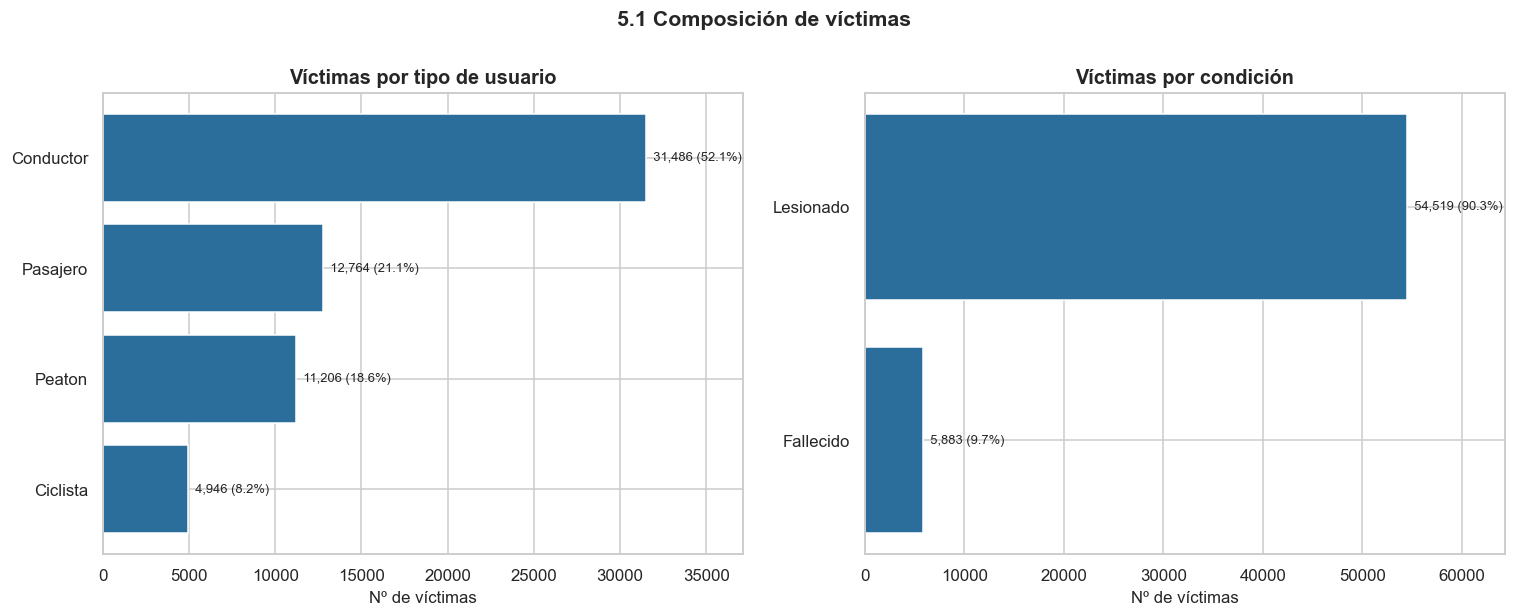

Víctimas por tipo de usuario:
  Conductor      :  31,486  (52.1%)
  Pasajero       :  12,764  (21.1%)
  Peaton         :  11,206  (18.6%)
  Ciclista       :   4,946  (8.2%)

Víctimas por condición:
  Lesionado      :  54,519  (90.3%)
  Fallecido      :   5,883  (9.7%)


In [25]:
# --- 5.1 Composición de víctimas por tipo de usuario y condición ---

# Distribución por tipo de usuario
comp_usuario = victimas["tipo_usuario"].value_counts()
pct_usuario = comp_usuario / comp_usuario.sum() * 100

# Distribución por condición (ileso / lesionado / fallecido)
comp_cond = victimas["condicion"].value_counts()
pct_cond = comp_cond / comp_cond.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel izquierdo: tipo de usuario
ax0 = axes[0]
d0 = comp_usuario[::-1]
p0 = pct_usuario[::-1]
ax0.barh(d0.index.astype(str), d0.values, color=COLOR_PRINCIPAL)
for y, (v, p) in enumerate(zip(d0.values, p0.values)):
    ax0.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)
ax0.set_title("Víctimas por tipo de usuario")
ax0.set_xlabel("Nº de víctimas")
ax0.set_xlim(0, comp_usuario.max() * 1.18)

# Panel derecho: condición
ax1 = axes[1]
d1 = comp_cond[::-1]
p1 = pct_cond[::-1]
ax1.barh(d1.index.astype(str), d1.values, color=COLOR_PRINCIPAL)
for y, (v, p) in enumerate(zip(d1.values, p1.values)):
    ax1.text(v, y, f"  {v:,.0f} ({p:.1f}%)", va="center", fontsize=8.5)
ax1.set_title("Víctimas por condición")
ax1.set_xlabel("Nº de víctimas")
ax1.set_xlim(0, comp_cond.max() * 1.18)

fig.suptitle("5.1 Composición de víctimas", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
cfg.save_fig(fig, "nb02_5_1_composicion_victimas")
plt.show()

print("Víctimas por tipo de usuario:")
for u in comp_usuario.index:
    print(f"  {str(u):<15}: {comp_usuario[u]:>7,}  ({pct_usuario[u]:.1f}%)")
print("\nVíctimas por condición:")
for c in comp_cond.index:
    print(f"  {str(c):<15}: {comp_cond[c]:>7,}  ({pct_cond[c]:.1f}%)")

### 5.2 Vulnerabilidad en desenlaces fatales

Se contrasta la participación de cada tipo de usuario en el **total de víctimas** frente a su
participación en las **víctimas fatales**. Si un grupo representa una fracción mayor entre los
fallecidos que entre el total, está sobre-representado en la mortalidad: es más vulnerable.

Dado que en la capa de víctimas el "motociclista" no es un tipo de usuario en sí mismo, sino un
conductor o pasajero cuyo vehículo es una motocicleta, el perfil de fallecidos se construye
combinando `tipo_usuario` con `tipo_vehiculo` para identificar a los **usuarios de motocicleta**
y a los **peatones**, reconocidos en la literatura como los usuarios más expuestos de la vía.

El indicador complementario es la **letalidad por grupo**: la proporción de fallecidos dentro de
las víctimas de cada tipo, que mide qué tan mortal resulta un siniestro para cada clase de
usuario.

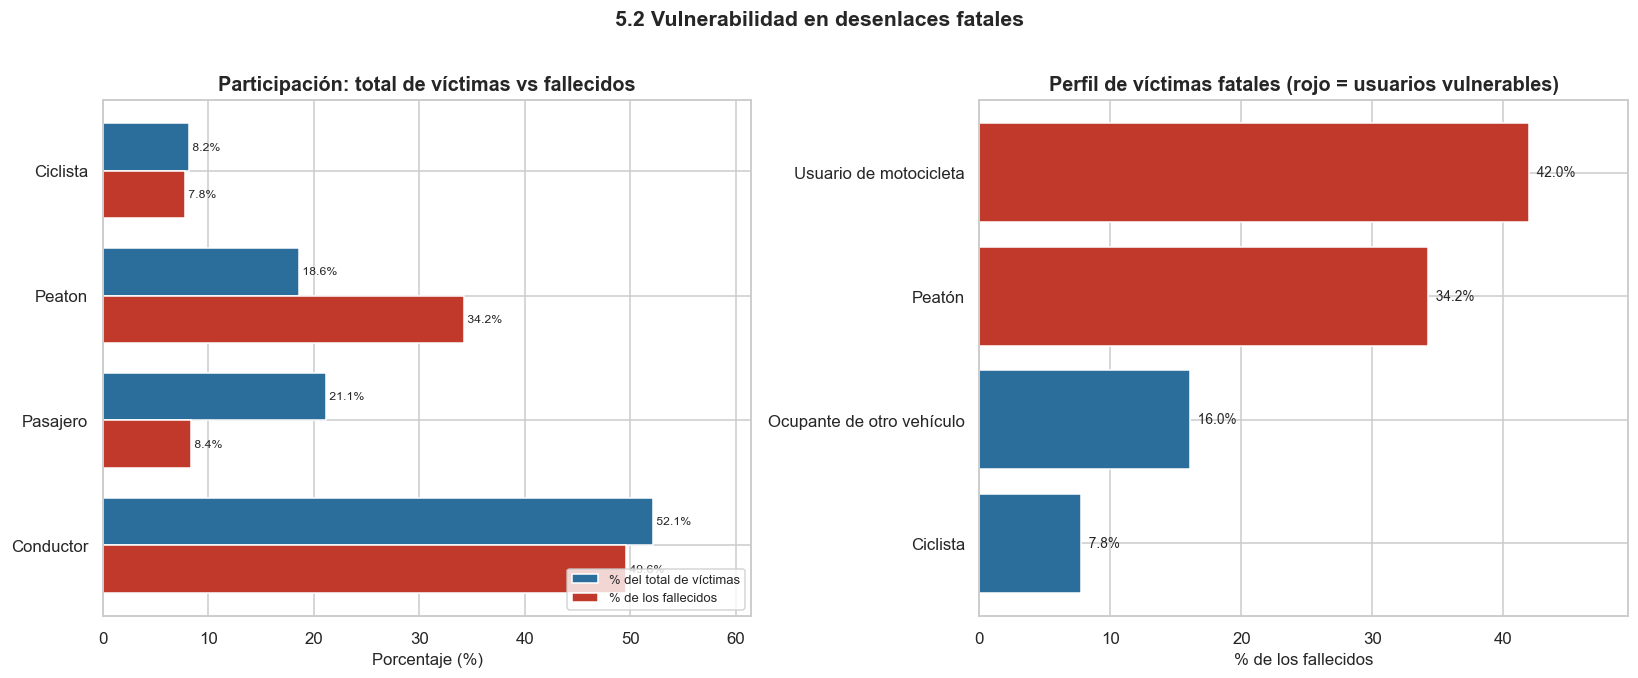

Perfil de víctimas fatales por grupo:
  Usuario de motocicleta    : 42.0%
  Peatón                    : 34.2%
  Ocupante de otro vehículo : 16.0%
  Ciclista                  : 7.8%

Letalidad por grupo (% de fallecidos entre las víctimas de ese grupo):
  Peatón                    : 18.0%
  Usuario de motocicleta    : 13.1%
  Ciclista                  : 9.2%
  Ocupante de otro vehículo : 3.7%


In [27]:
# --- 5.2 Vulnerabilidad en desenlaces fatales ---
ES_FATAL = victimas["condicion"] == "Fallecido"

# --- (a) Composición: total de víctimas vs fallecidos, por tipo de usuario ---
comp_total = victimas["tipo_usuario"].value_counts(normalize=True) * 100
comp_fatal = victimas.loc[ES_FATAL, "tipo_usuario"].value_counts(normalize=True) * 100

orden = comp_total.index.tolist()
comp_total = comp_total.reindex(orden)
comp_fatal = comp_fatal.reindex(orden)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: barras agrupadas total vs fatal
ax0 = axes[0]
y = np.arange(len(orden))
h = 0.38
ax0.barh(y + h/2, comp_total.values, height=h, color=COLOR_PRINCIPAL, label="% del total de víctimas")
ax0.barh(y - h/2, comp_fatal.values, height=h, color=COLOR_ACENTO, label="% de los fallecidos")
ax0.set_yticks(y)
ax0.set_yticklabels(orden)
ax0.set_xlabel("Porcentaje (%)")
ax0.set_title("Participación: total de víctimas vs fallecidos")
ax0.legend(fontsize=8.5, loc="lower right")
for i in range(len(orden)):
    ax0.text(comp_total.values[i], y[i] + h/2, f" {comp_total.values[i]:.1f}%", va="center", fontsize=8)
    ax0.text(comp_fatal.values[i], y[i] - h/2, f" {comp_fatal.values[i]:.1f}%", va="center", fontsize=8)
ax0.set_xlim(0, max(comp_total.max(), comp_fatal.max()) * 1.18)

# --- (b) Perfil de fallecidos combinando usuario + vehículo (motociclista/peatón) ---
falle = victimas[ES_FATAL].copy()

def clasif_vulnerable(row):
    if row["tipo_usuario"] == "Peaton":
        return "Peatón"
    if row["tipo_vehiculo"] == "Motocicleta":
        return "Usuario de motocicleta"
    if row["tipo_usuario"] == "Ciclista" or row["tipo_vehiculo"] == "Bicicleta":
        return "Ciclista"
    return "Ocupante de otro vehículo"

falle["grupo_vuln"] = falle.apply(clasif_vulnerable, axis=1)
perfil_fatal = falle["grupo_vuln"].value_counts(normalize=True) * 100

ax1 = axes[1]
d1 = perfil_fatal.sort_values()
colores = [COLOR_ACENTO if g in ("Usuario de motocicleta", "Peatón") else COLOR_PRINCIPAL
           for g in d1.index]
ax1.barh(d1.index.astype(str), d1.values, color=colores)
for yv, v in enumerate(d1.values):
    ax1.text(v, yv, f"  {v:.1f}%", va="center", fontsize=9)
ax1.set_title("Perfil de víctimas fatales (rojo = usuarios vulnerables)")
ax1.set_xlabel("% de los fallecidos")
ax1.set_xlim(0, d1.max() * 1.18)

fig.suptitle("5.2 Vulnerabilidad en desenlaces fatales", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_5_2_vulnerabilidad_fatal")
plt.show()

# --- (c) Letalidad por grupo vulnerable (sobre TODAS las víctimas, no solo fatales) ---
victimas_vuln = victimas.copy()
victimas_vuln["grupo_vuln"] = victimas_vuln.apply(clasif_vulnerable, axis=1)
letalidad = (
    victimas_vuln.assign(fatal=victimas_vuln["condicion"] == "Fallecido")
                 .groupby("grupo_vuln")["fatal"]
                 .mean()
                 .mul(100)
                 .sort_values(ascending=False)
)

print("Perfil de víctimas fatales por grupo:")
for g, v in perfil_fatal.sort_values(ascending=False).items():
    print(f"  {g:<26}: {v:.1f}%")

print("\nLetalidad por grupo (% de fallecidos entre las víctimas de ese grupo):")
for g, v in letalidad.items():
    print(f"  {g:<26}: {v:.1f}%")

### 5.3 Severidad por rango etario

Se analiza la distribución de víctimas por `rango_etario`, distinguiendo entre lesionados y
fallecidos, para identificar qué grupos de edad concentran la siniestralidad y cuáles presentan
mayor letalidad.

Interesan dos lecturas:

- **Volumen por edad**: qué grupos etarios aportan más víctimas en términos absolutos, lo que
  suele reflejar la composición de la población económicamente activa y con mayor movilidad.
- **Letalidad por edad**: la proporción de fallecidos dentro de las víctimas de cada grupo, que
  permite ver si la gravedad del desenlace varía con la edad (p. ej. mayor fragilidad en edades
  avanzadas).

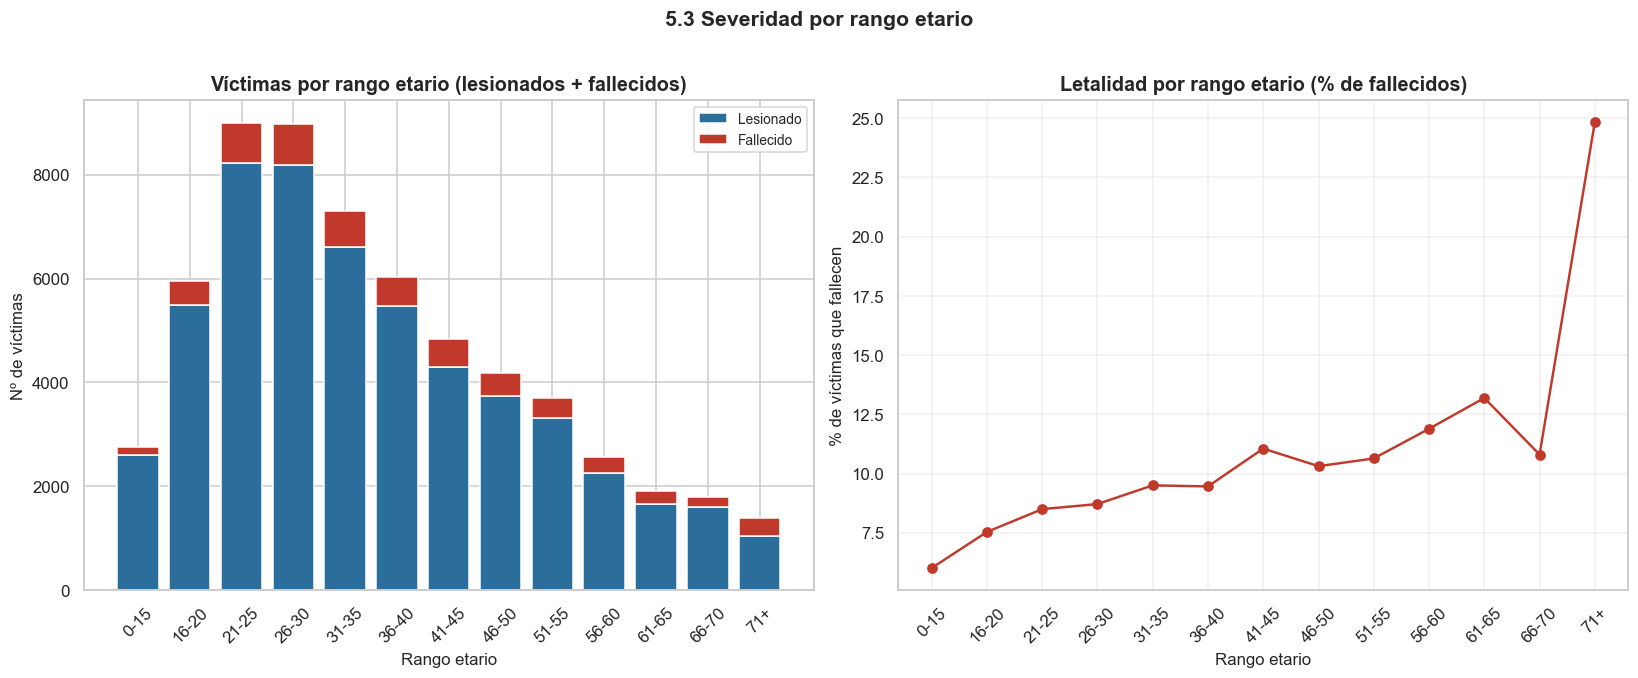

Grupo etario con más víctimas: 21-25 (8,991 víctimas)
Grupo etario con mayor letalidad: 71+ (24.8% de fallecidos)


In [28]:
# --- 5.3 Severidad por rango etario ---
# Orden etario natural (según el catálogo de 13 grupos del dataset)
ORDEN_EDAD = ["0-15","16-20","21-25","26-30","31-35","36-40","41-45",
              "46-50","51-55","56-60","61-65","66-70","71+"]

vic = victimas.copy()
vic["es_fatal"] = vic["condicion"] == "Fallecido"

# Conteo por rango etario y condición
tabla_edad = (vic.groupby(["rango_etario", "condicion"]).size()
                 .unstack(fill_value=0)
                 .reindex(ORDEN_EDAD))

# Letalidad por edad
letalidad_edad = (vic.groupby("rango_etario")["es_fatal"].mean() * 100).reindex(ORDEN_EDAD)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: barras apiladas lesionado + fallecido
ax0 = axes[0]
lesion = tabla_edad.get("Lesionado", pd.Series(0, index=ORDEN_EDAD))
falls  = tabla_edad.get("Fallecido", pd.Series(0, index=ORDEN_EDAD))
ax0.bar(ORDEN_EDAD, lesion.values, color=COLOR_PRINCIPAL, label="Lesionado")
ax0.bar(ORDEN_EDAD, falls.values, bottom=lesion.values, color=COLOR_ACENTO, label="Fallecido")
ax0.set_title("Víctimas por rango etario (lesionados + fallecidos)")
ax0.set_xlabel("Rango etario")
ax0.set_ylabel("Nº de víctimas")
ax0.legend(fontsize=9)
ax0.tick_params(axis="x", rotation=45)

# Panel derecho: letalidad por edad
ax1 = axes[1]
ax1.plot(ORDEN_EDAD, letalidad_edad.values, color=COLOR_ACENTO, marker="o", linewidth=1.6)
ax1.set_title("Letalidad por rango etario (% de fallecidos)")
ax1.set_xlabel("Rango etario")
ax1.set_ylabel("% de víctimas que fallecen")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3)

fig.suptitle("5.3 Severidad por rango etario", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_5_3_severidad_etaria")
plt.show()

# Grupo etario con más víctimas y con mayor letalidad
grupo_mas_victimas = tabla_edad.sum(axis=1).idxmax()
grupo_mas_letal = letalidad_edad.idxmax()
print(f"Grupo etario con más víctimas: {grupo_mas_victimas} "
      f"({tabla_edad.sum(axis=1).max():,.0f} víctimas)")
print(f"Grupo etario con mayor letalidad: {grupo_mas_letal} "
      f"({letalidad_edad.max():.1f}% de fallecidos)")

### 5.4 Síntesis de víctimas y severidad

- **Composición**: las víctimas se reparten en conductores (52.1%), pasajeros (21.1%), peatones
  (18.6%) y ciclistas (8.2%). Del total, el 90.3% resulta lesionado y el 9.7% fallece.
- **Vulnerabilidad diferencial**: al reagrupar por tipo de usuario y vehículo, los **usuarios de
  motocicleta (42.0%)** y los **peatones (34.2%)** concentran más de tres cuartas partes de las
  víctimas fatales. Ambos grupos están sobre-representados en la mortalidad respecto a su
  participación en el total de víctimas.
- **Letalidad por usuario**: el peatón es el usuario más letal (18.0% de sus víctimas fallecen),
  seguido del motociclista (13.1%); el ocupante de vehículo cerrado es el más protegido (3.7%).
- **Edad**: el volumen de víctimas se concentra en 21–35 años (población joven y móvil), mientras
  que la letalidad crece con la edad, alcanzando su máximo en el grupo de 71+ años (24.8%). El
  grupo que más víctimas aporta no es el de mayor letalidad.

**Decisiones para NB03**: el grupo de usuario vulnerable (motociclista / peatón / ciclista / otro)
y el rango etario son variables candidatas para caracterizar la severidad; la letalidad
diferencial indica que la gravedad del desenlace no es homogénea entre grupos.

In [29]:
# --- Inspección rápida de estaciones y clima (fuentes aún no usadas en NB02) ---

print("=" * 60)
print("ESTACIONES (catálogo, 7 filas)")
print("=" * 60)
print("Columnas:", list(estaciones.columns))
print()
print(estaciones.to_string(index=False))

print("\n" + "=" * 60)
print("CLIMA (horario unificado)")
print("=" * 60)
print("Columnas:", list(clima.columns))
print("\nPrimeras filas:")
print(clima.head(5).to_string(index=False))

print("\nTipos de dato relevantes:")
print(clima.dtypes)

# Intento de identificar la columna que distingue estaciones
print("\nValores únicos por columna candidata a 'estación' (si existe):")
for col in clima.columns:
    nun = clima[col].nunique(dropna=True)
    if 1 < nun <= 12 and clima[col].dtype == object:
        print(f"  {col}: {sorted(clima[col].dropna().unique())}")

ESTACIONES (catálogo, 7 filas)
Columnas: ['id', 'nombre', 'pais', 'region', 'latitud', 'longitud', 'elevacion', 'timezone']

   id                               nombre pais region  latitud  longitud  elevacion            timezone
78650                             Acajutla   SV     SO    13.57    -89.83         15 America/El_Salvador
78663              San Salvador / Ilopango   SV     SS    13.70    -89.12        616 America/El_Salvador
78655                Santa Ana / El Palmar   SV     SA    13.98    -89.57        725 America/El_Salvador
78670              San Miguel / El Papalon   SV     SM    13.45    -88.12         80 America/El_Salvador
78672                             La Union   SV     UN    13.33    -87.88         95 America/El_Salvador
78666 El Salvador Intl. Airport / Comalapa   SV     PZ    13.43    -89.05         25 America/El_Salvador
78662                         San Salvador   SV     SS    13.72    -89.20        698 America/El_Salvador

CLIMA (horario unificado)
Columnas

## 6. Relación clima–siniestralidad

El clima es una de las variables centrales del proyecto. Esta sección caracteriza **cómo la
precipitación se relaciona con la siniestralidad**, cruzando por primera vez la capa de eventos
con datos meteorológicos **reales** (registros horarios de Meteostat, 2022–2026).

### Asignación de estación meteorológica por cercanía

El Salvador dispone de un número reducido de estaciones. Para asignar clima a cada distrito se
usa el criterio de **estación más cercana con datos de precipitación usables**:

- Se calcula la distancia geográfica de cada distrito a cada estación y se asigna la más próxima.
- Se **excluye la estación de San Salvador centro** (78662) por su baja completitud de
  precipitación (22.7%, documentada en la Sección 1), de modo que los distritos del AMSS se
  asignan a **Ilopango** (78663), la estación con datos usables más cercana.
- Se excluye también La Unión (sin registros en la fuente de clima cargada).

Quedan cinco estaciones de referencia: Ilopango (AMSS), Santa Ana (occidente-centro), Acajutla
(costa occidental), San Miguel (oriente) y Comalapa (zona paracentral/aeropuerto).

### Resolución de la señal climática

La capa de eventos es sintética calibrada con una señal **estacional** (temporada lluviosa
May–Oct), no con el registro diario de lluvia. Por ello el análisis distingue dos resoluciones:

- **Estacional/mensual**: donde la relación clima–siniestralidad es más fuerte y directa.
- **Diaria**: el cruce fino día-a-día, que permite ver a qué resolución vive efectivamente la
  señal.

Ambas lecturas son legítimas y se interpretan en su contexto. El *join* se construye aquí de
forma exploratoria; su versión reproducible como *feature* se implementa en NB03.

In [30]:
# --- 6. Construcción del mapeo distrito -> estación más cercana (Opción 1: GPS) ---

# Puente entre 'region' del catálogo estaciones y 'estacion' (código en clima)
# region catálogo -> código en clima
REGION_A_CODIGO = {
    "SO": "SO",   # Acajutla
    "SS": "IL",   # zona San Salvador -> se sirve con Ilopango (código IL en clima)
    "SA": "SA",   # Santa Ana
    "SM": "SM",   # San Miguel
    "PZ": "PAZ",  # Comalapa (región PZ -> código PAZ en clima)
    "UN": "UN",   # La Unión (sin datos en clima; se excluirá)
}

# Estaciones a EXCLUIR del join:
#  - 78662: San Salvador centro (baja completitud de prcp; su zona la cubre Ilopango 78663)
#  - 78672: La Unión (sin datos en la fuente de clima cargada)
IDS_EXCLUIR = {78662, 78672}

# Estaciones usables: catálogo con datos de precipitación
est_uso = estaciones[~estaciones["id"].isin(IDS_EXCLUIR)].copy()
est_uso["codigo_clima"] = est_uso["region"].map(REGION_A_CODIGO)

# Verificar que todas las estaciones usables tienen código de clima válido
codigos_clima_disponibles = set(clima["estacion"].unique())
est_uso = est_uso[est_uso["codigo_clima"].isin(codigos_clima_disponibles)]

print("Estaciones usables para el join (con datos de precipitación):")
print(est_uso[["id", "nombre", "region", "codigo_clima", "latitud", "longitud"]].to_string(index=False))

# --- Coordenadas de cada distrito (promedio de los siniestros del distrito) ---
# Se usa el centroide empírico de los siniestros como proxy de ubicación del distrito.
coord_dist = (siniestros.groupby("distrito")
                        .agg(lat=("latitud", "mean"), lon=("longitud", "mean"))
                        .reset_index())

# --- Asignar a cada distrito la estación usable más cercana (distancia euclídea en grados) ---
est_lat = est_uso["latitud"].values
est_lon = est_uso["longitud"].values
est_cod = est_uso["codigo_clima"].values
est_nom = est_uso["nombre"].values

def estacion_mas_cercana(lat, lon):
    d2 = (est_lat - lat) ** 2 + (est_lon - lon) ** 2
    i = int(np.argmin(d2))
    return pd.Series({"estacion_asignada": est_cod[i], "estacion_nombre": est_nom[i]})

coord_dist[["estacion_asignada", "estacion_nombre"]] = coord_dist.apply(
    lambda r: estacion_mas_cercana(r["lat"], r["lon"]), axis=1
)

# Resumen: cuántos distritos quedaron asignados a cada estación
print("\nDistritos asignados a cada estación:")
resumen_asig = coord_dist["estacion_nombre"].value_counts()
for nom, n in resumen_asig.items():
    print(f"  {nom:<40}: {n:>3} distritos")

# Guardamos el mapeo para el join posterior (dict distrito -> código estación)
MAPA_DIST_EST = dict(zip(coord_dist["distrito"], coord_dist["estacion_asignada"]))
print(f"\nMapeo construido para {len(MAPA_DIST_EST)} distritos.")

Estaciones usables para el join (con datos de precipitación):
   id                               nombre region codigo_clima  latitud  longitud
78650                             Acajutla     SO           SO    13.57    -89.83
78663              San Salvador / Ilopango     SS           IL    13.70    -89.12
78655                Santa Ana / El Palmar     SA           SA    13.98    -89.57
78670              San Miguel / El Papalon     SM           SM    13.45    -88.12
78666 El Salvador Intl. Airport / Comalapa     PZ          PAZ    13.43    -89.05

Distritos asignados a cada estación:
  San Salvador / Ilopango                 :  41 distritos
  San Miguel / El Papalon                 :  27 distritos
  Santa Ana / El Palmar                   :  16 distritos
  Acajutla                                :  11 distritos
  El Salvador Intl. Airport / Comalapa    :   8 distritos

Mapeo construido para 103 distritos.


### 6.1 Relación estacional: precipitación mensual vs siniestralidad

Se contrasta la **precipitación mensual promedio** (agregando el registro horario real de las
estaciones) con el **promedio de siniestros por mes**. Esta es la resolución donde la relación
clima–siniestralidad se manifiesta con más claridad: los meses de mayor lluvia coinciden con la
temporada de mayor siniestralidad (May–Oct), ya caracterizada en la Sección 3.2.

Se presentan dos vistas:

- El perfil mensual conjunto de lluvia y siniestros, para observar visualmente si ambas series
  siguen el mismo patrón estacional.
- La correlación entre ambas a nivel mensual, que cuantifica la fuerza de esa relación.

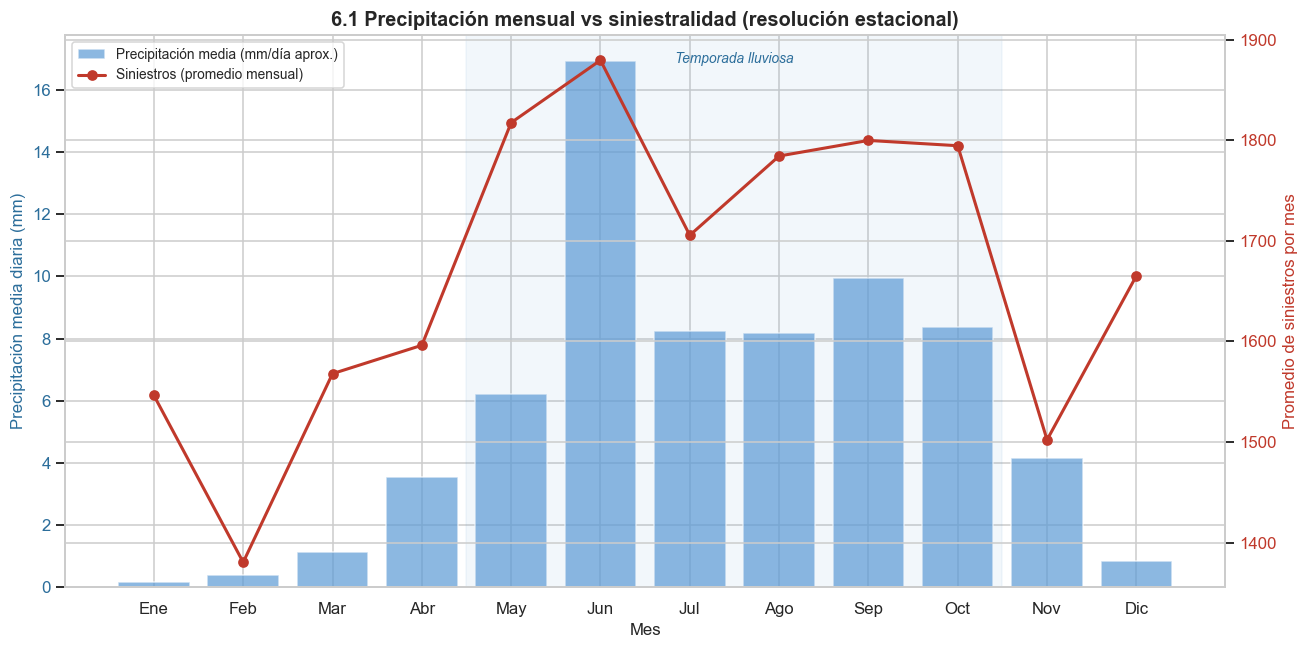

Correlación mensual (precipitación vs siniestros): r = 0.814

Precipitación media diaria por mes (mm aprox.):
  Ene:   0.2 mm   siniestros prom: 1546.4
  Feb:   0.4 mm   siniestros prom: 1380.6
  Mar:   1.1 mm   siniestros prom: 1568.0
  Abr:   3.5 mm   siniestros prom: 1596.2
  May:   6.2 mm   siniestros prom: 1817.4
  Jun:  16.9 mm   siniestros prom: 1879.4
  Jul:   8.2 mm   siniestros prom: 1705.5
  Ago:   8.2 mm   siniestros prom: 1784.2
  Sep:  10.0 mm   siniestros prom: 1799.8
  Oct:   8.4 mm   siniestros prom: 1794.5
  Nov:   4.2 mm   siniestros prom: 1502.2
  Dic:   0.9 mm   siniestros prom: 1665.2


In [31]:
# --- 6.1 Relación estacional: precipitación mensual vs siniestros mensuales ---

# Precipitación mensual promedio (promediando sobre estaciones y años, por mes calendario)
clima_mes = clima.copy()
clima_mes["mes"] = clima_mes["time"].dt.month
# Lluvia diaria por estación -> luego promedio mensual (evita sesgo por horas)
prcp_mensual = (clima_mes.groupby("mes")["prcp"].mean() * 24)  # mm/hora prom -> aprox mm/día

# Siniestros: promedio por mes (mismo criterio que sección 3.2)
sin_mes = siniestros.assign(anio=siniestros["fecha"].dt.year,
                            mes=siniestros["fecha"].dt.month)
por_anio_mes = sin_mes.groupby(["anio", "mes"]).size().rename("n").reset_index()
sin_mensual = por_anio_mes.groupby("mes")["n"].mean().reindex(range(1, 13))

MESES = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

# --- Gráfico de doble eje: lluvia (barras) + siniestros (línea) ---
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(1, 13)
ax1.bar(x, prcp_mensual.reindex(range(1, 13)).values, color="#5B9BD5", alpha=0.7,
        label="Precipitación media (mm/día aprox.)")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Precipitación media diaria (mm)", color="#2C6E9B")
ax1.set_xticks(x)
ax1.set_xticklabels(MESES)
ax1.tick_params(axis="y", labelcolor="#2C6E9B")

ax2 = ax1.twinx()
ax2.plot(x, sin_mensual.values, color=COLOR_ACENTO, marker="o", linewidth=2,
         label="Siniestros (promedio mensual)")
ax2.set_ylabel("Promedio de siniestros por mes", color=COLOR_ACENTO)
ax2.tick_params(axis="y", labelcolor=COLOR_ACENTO)

# Sombrear temporada lluviosa May-Oct
ax1.axvspan(4.5, 10.5, color="#5B9BD5", alpha=0.08)
ax1.text(7.5, ax1.get_ylim()[1]*0.95, "Temporada lluviosa", ha="center",
         fontsize=9, color="#2C6E9B", style="italic")

ax1.set_title("6.1 Precipitación mensual vs siniestralidad (resolución estacional)")

# Leyendas combinadas
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="upper left", fontsize=9)

fig.tight_layout()
cfg.save_fig(fig, "nb02_6_1_estacional_lluvia_siniestros")
plt.show()

# --- Correlación mensual entre lluvia y siniestros ---
df_corr = pd.DataFrame({
    "prcp": prcp_mensual.reindex(range(1, 13)).values,
    "siniestros": sin_mensual.values,
})
corr_mensual = df_corr["prcp"].corr(df_corr["siniestros"])
print(f"Correlación mensual (precipitación vs siniestros): r = {corr_mensual:.3f}")
print(f"\nPrecipitación media diaria por mes (mm aprox.):")
for m in range(1, 13):
    print(f"  {MESES[m-1]}: {prcp_mensual.get(m, float('nan')):5.1f} mm   "
          f"siniestros prom: {sin_mensual.get(m, float('nan')):6.1f}")

### 6.2 Resolución diaria: ¿la señal es estacional o día-a-día?

La correlación estacional (r ≈ 0.81) es fuerte. Cabe preguntarse si esa relación se mantiene al
**máximo detalle temporal**: ¿los días de más lluvia son también los días de más siniestros,
dentro de un mismo período?

Para responderlo se construye el *join* diario real usando el mapeo distrito→estación por
cercanía (construido en 6.0): a cada día se le asocia la precipitación de su estación
correspondiente, y se compara con el número de siniestros de ese día.

Es esperable que la correlación diaria sea **más débil** que la estacional. La capa de eventos
fue calibrada con una señal de temporada (mensual), no con el registro de lluvia de cada día
concreto. Un resultado diario débil no contradice la relación estacional: indica que, en este
dato, **la señal climática vive a resolución de temporada**, que es además la resolución
relevante para el modelado de riesgo por zona y período. Este es un hallazgo metodológico sobre
la naturaleza de los datos, no una ausencia de relación clima–siniestralidad.

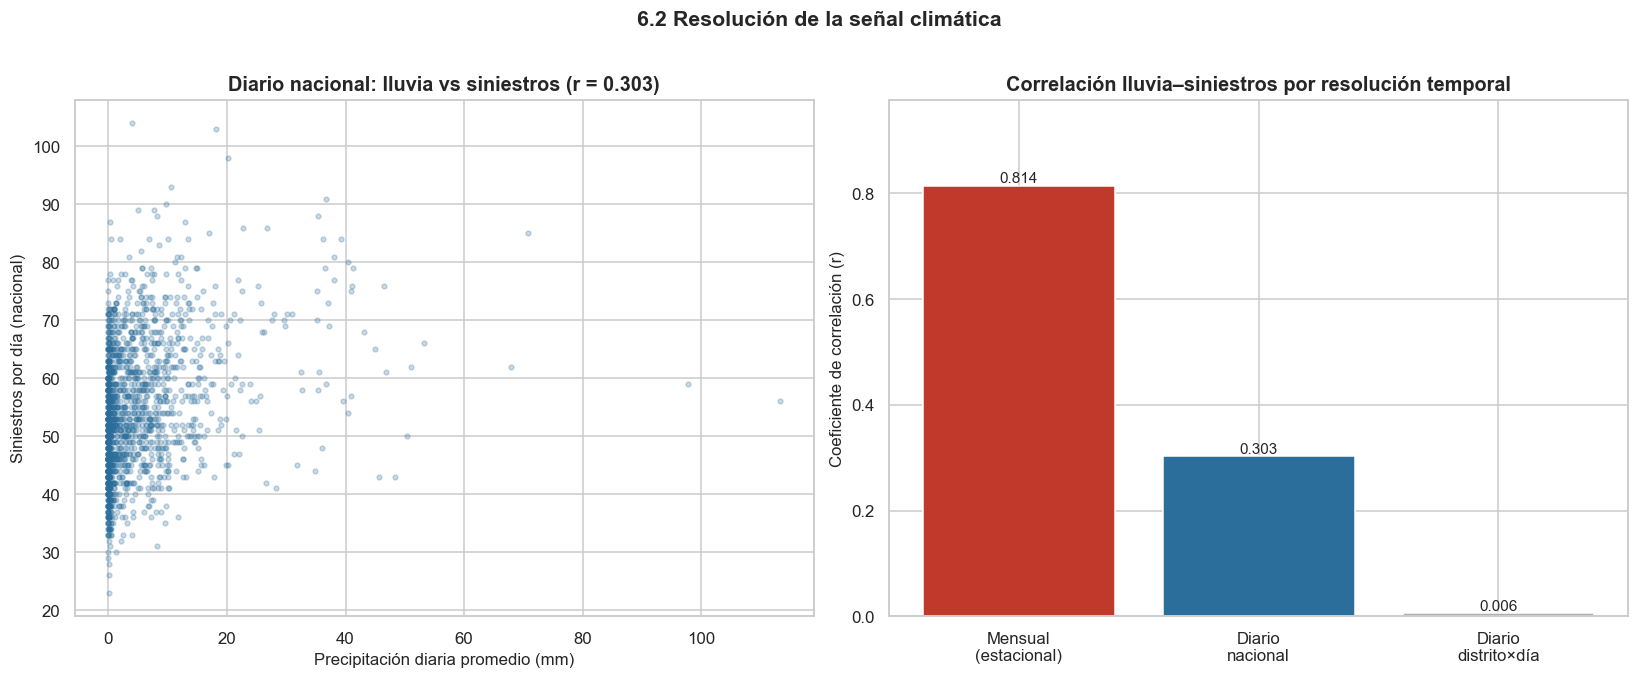

Correlación MENSUAL (estacional):      r = 0.814
Correlación DIARIA nacional:           r = 0.303
Correlación DIARIA distrito×día:       r = 0.006

Filas del join diario distrito×día: 46,039


In [32]:
# --- 6.2 Join diario: precipitación del día (por estación asignada) vs siniestros del día ---

# Precipitación diaria por estación: sumar la lluvia horaria por (estación, fecha)
clima_d = clima.copy()
clima_d["fecha"] = clima_d["time"].dt.normalize()
prcp_diaria = (clima_d.groupby(["estacion", "fecha"])["prcp"].sum()
                      .rename("prcp_dia").reset_index())

# Siniestros diarios por distrito
sin_d = (siniestros.assign(fecha_norm=siniestros["fecha"].dt.normalize())
                   .groupby(["distrito", "fecha_norm"]).size()
                   .rename("n_siniestros").reset_index())

# Asignar a cada distrito su estación (mapeo por cercanía) y unir la lluvia de ESE día
sin_d["estacion"] = sin_d["distrito"].map(MAPA_DIST_EST)
sin_d = sin_d.merge(prcp_diaria, left_on=["estacion", "fecha_norm"],
                    right_on=["estacion", "fecha"], how="left")

# --- (a) Correlación diaria a nivel distrito×día ---
val = sin_d.dropna(subset=["prcp_dia"])
corr_diaria_dist = val["prcp_dia"].corr(val["n_siniestros"])

# --- (b) Correlación diaria a nivel nacional (agregado por día) ---
# Siniestros totales por día vs lluvia promedio de las estaciones ese día
sin_nac = (siniestros.assign(fecha_norm=siniestros["fecha"].dt.normalize())
                     .groupby("fecha_norm").size().rename("n_siniestros"))
prcp_nac = prcp_diaria.groupby("fecha")["prcp_dia"].mean().rename("prcp_prom")
nac = pd.concat([sin_nac, prcp_nac], axis=1).dropna()
corr_diaria_nac = nac["prcp_prom"].corr(nac["n_siniestros"])

# --- Gráfico: dispersión diaria nacional ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax0 = axes[0]
ax0.scatter(nac["prcp_prom"], nac["n_siniestros"], s=10, alpha=0.25, color=COLOR_PRINCIPAL)
ax0.set_title(f"Diario nacional: lluvia vs siniestros (r = {corr_diaria_nac:.3f})")
ax0.set_xlabel("Precipitación diaria promedio (mm)")
ax0.set_ylabel("Siniestros por día (nacional)")

# Comparación de correlaciones: estacional vs diaria
ax1 = axes[1]
niveles = ["Mensual\n(estacional)", "Diario\nnacional", "Diario\ndistrito×día"]
valores = [0.814, corr_diaria_nac, corr_diaria_dist]
colores = [COLOR_ACENTO, COLOR_PRINCIPAL, COLOR_PARCIAL]
barras = ax1.bar(niveles, valores, color=colores)
for b, v in zip(barras, valores):
    ax1.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax1.set_title("Correlación lluvia–siniestros por resolución temporal")
ax1.set_ylabel("Coeficiente de correlación (r)")
ax1.set_ylim(0, max(valores)*1.2)
ax1.axhline(0, color="gray", linewidth=0.8)

fig.suptitle("6.2 Resolución de la señal climática", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_6_2_resolucion_diaria")
plt.show()

print(f"Correlación MENSUAL (estacional):      r = 0.814")
print(f"Correlación DIARIA nacional:           r = {corr_diaria_nac:.3f}")
print(f"Correlación DIARIA distrito×día:       r = {corr_diaria_dist:.3f}")
print(f"\nFilas del join diario distrito×día: {len(val):,}")

### 6.3 Síntesis de la relación clima–siniestralidad

Se cruzó la capa de eventos con datos meteorológicos **reales** (Meteostat, 2022–2026), asignando
a cada distrito su estación más cercana con precipitación usable (criterio GPS, con Ilopango
sirviendo al AMSS y exclusión de la estación de San Salvador centro por baja completitud).

El hallazgo central es que **la relación clima–siniestralidad depende de la resolución temporal**:

| Resolución | Correlación (r) | Interpretación |
| --- | --- | --- |
| Mensual (estacional) | 0.814 | Fuerte: los meses lluviosos concentran más siniestros |
| Diaria nacional | 0.303 | Débil: el registro diario predice poco por sí solo |
| Diaria distrito×día | 0.006 | Prácticamente nula al máximo detalle |

**Lectura**: el clima afecta la siniestralidad principalmente como **patrón estacional** (la
temporada lluviosa May–Oct eleva el riesgo, con un pico conjunto lluvia–siniestros en junio), no
como evento diario puntual. La correlación estacional confirma la temporada lluviosa como factor
de riesgo; la caída al nivel diario indica que, en este conjunto, la señal climática vive a
resolución de temporada.

Se observó además que algunos meses se apartan del patrón puramente climático (p. ej. diciembre,
con siniestralidad relativamente alta pese a baja lluvia), lo que sugiere la influencia de
factores no climáticos como la movilidad de fin de año.

**Decisiones para NB03**: la variable climática relevante para el modelado es de tipo
**estacional/mensual** (indicador de temporada lluviosa y/o precipitación agregada del período),
no la precipitación diaria puntual. El *join* distrito→estación construido aquí se reutiliza como
base de esa *feature*.

## 7. Relaciones bivariadas y correlaciones

Las secciones anteriores analizaron las variables principalmente de forma individual. Esta sección
examina **asociaciones entre pares de variables**, para detectar relaciones que el análisis
univariado no revela y que pueden orientar el *feature engineering*.

Se analizan tres cruces categóricos y una matriz de correlación:

- **zona × tipo de siniestro**: si la composición de los siniestros difiere entre áreas urbanas y
  rurales.
- **franja horaria × severidad**: si algunas franjas del día concentran desenlaces más graves,
  más allá de su volumen.
- **condición de la vía × tipo de siniestro**: si el estado de la superficie (ligado al clima) se
  asocia a tipos de siniestro distintos.

Los cruces categóricos se presentan como proporciones normalizadas por fila (heatmaps), que
permiten comparar perfiles independientemente del volumen absoluto de cada categoría.

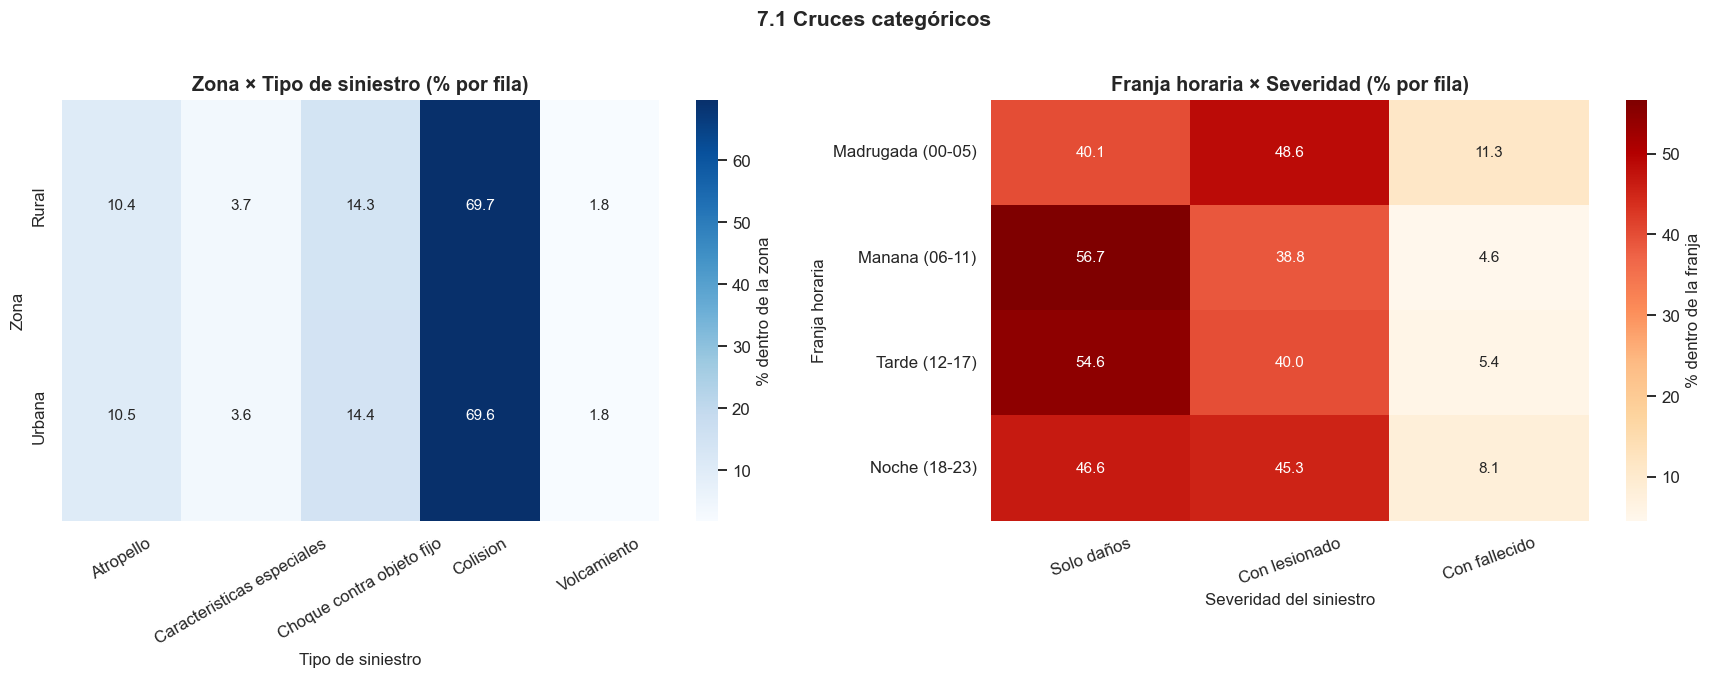

Severidad por franja horaria (% dentro de la franja):
severidad          Solo daños  Con lesionado  Con fallecido
franja_horaria                                             
Madrugada (00-05)       40.09          48.61          11.31
Manana (06-11)          56.67          38.78           4.56
Tarde (12-17)           54.64          39.95           5.41
Noche (18-23)           46.60          45.34           8.06

Franja con mayor % de siniestros con fallecido:
  Madrugada (00-05): 11.31%


In [33]:
# --- 7. Cruces categóricos (heatmaps normalizados por fila) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- (1) zona × tipo_siniestro (normalizado por zona) ---
ct1 = pd.crosstab(siniestros["zona"], siniestros["tipo_siniestro"], normalize="index") * 100
sns.heatmap(ct1, annot=True, fmt=".1f", cmap="Blues", ax=axes[0],
            cbar_kws={"label": "% dentro de la zona"})
axes[0].set_title("Zona × Tipo de siniestro (% por fila)")
axes[0].set_xlabel("Tipo de siniestro")
axes[0].set_ylabel("Zona")
axes[0].tick_params(axis="x", rotation=30)

# --- (2) franja_horaria × severidad ---
# Severidad del siniestro: derivada de fallecidos/lesionados (exploratoria)
def nivel_sev(row):
    if row["fallecidos"] > 0:
        return "Con fallecido"
    if row["lesionados"] > 0:
        return "Con lesionado"
    return "Solo daños"

sev = siniestros.assign(severidad=siniestros.apply(nivel_sev, axis=1))
ORDEN_FRANJA = ["Madrugada (00-05)", "Manana (06-11)", "Tarde (12-17)", "Noche (18-23)"]
ORDEN_SEV = ["Solo daños", "Con lesionado", "Con fallecido"]

ct2 = pd.crosstab(sev["franja_horaria"], sev["severidad"], normalize="index") * 100
ct2 = ct2.reindex(index=[f for f in ORDEN_FRANJA if f in ct2.index],
                  columns=ORDEN_SEV)
sns.heatmap(ct2, annot=True, fmt=".1f", cmap="OrRd", ax=axes[1],
            cbar_kws={"label": "% dentro de la franja"})
axes[1].set_title("Franja horaria × Severidad (% por fila)")
axes[1].set_xlabel("Severidad del siniestro")
axes[1].set_ylabel("Franja horaria")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("7.1 Cruces categóricos", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_7_1_crosstabs")
plt.show()

# Prints de apoyo: el % de "con fallecido" por franja (para ver franja más letal)
print("Severidad por franja horaria (% dentro de la franja):")
print(ct2.round(2).to_string())
print("\nFranja con mayor % de siniestros con fallecido:")
col_fatal = ct2["Con fallecido"]
print(f"  {col_fatal.idxmax()}: {col_fatal.max():.2f}%")

### 7.2 Condición de la vía y matriz de correlación

Se completa el análisis bivariado con:

- **Condición de la vía × tipo de siniestro**: dado que la condición de la superficie está ligada
  al clima (vía húmeda en temporada lluviosa), se examina si se asocia a tipos de siniestro
  distintos.
- **Matriz de correlación**: se calcula sobre un conjunto de variables numéricas y derivadas
  exploratorias (severidad, indicadores temporales, precipitación asignada) para identificar
  asociaciones lineales que orienten el *feature engineering*. Se interpretan con cautela: las
  correlaciones lineales no capturan relaciones no lineales ni de conteo, que se abordan en el
  modelado.

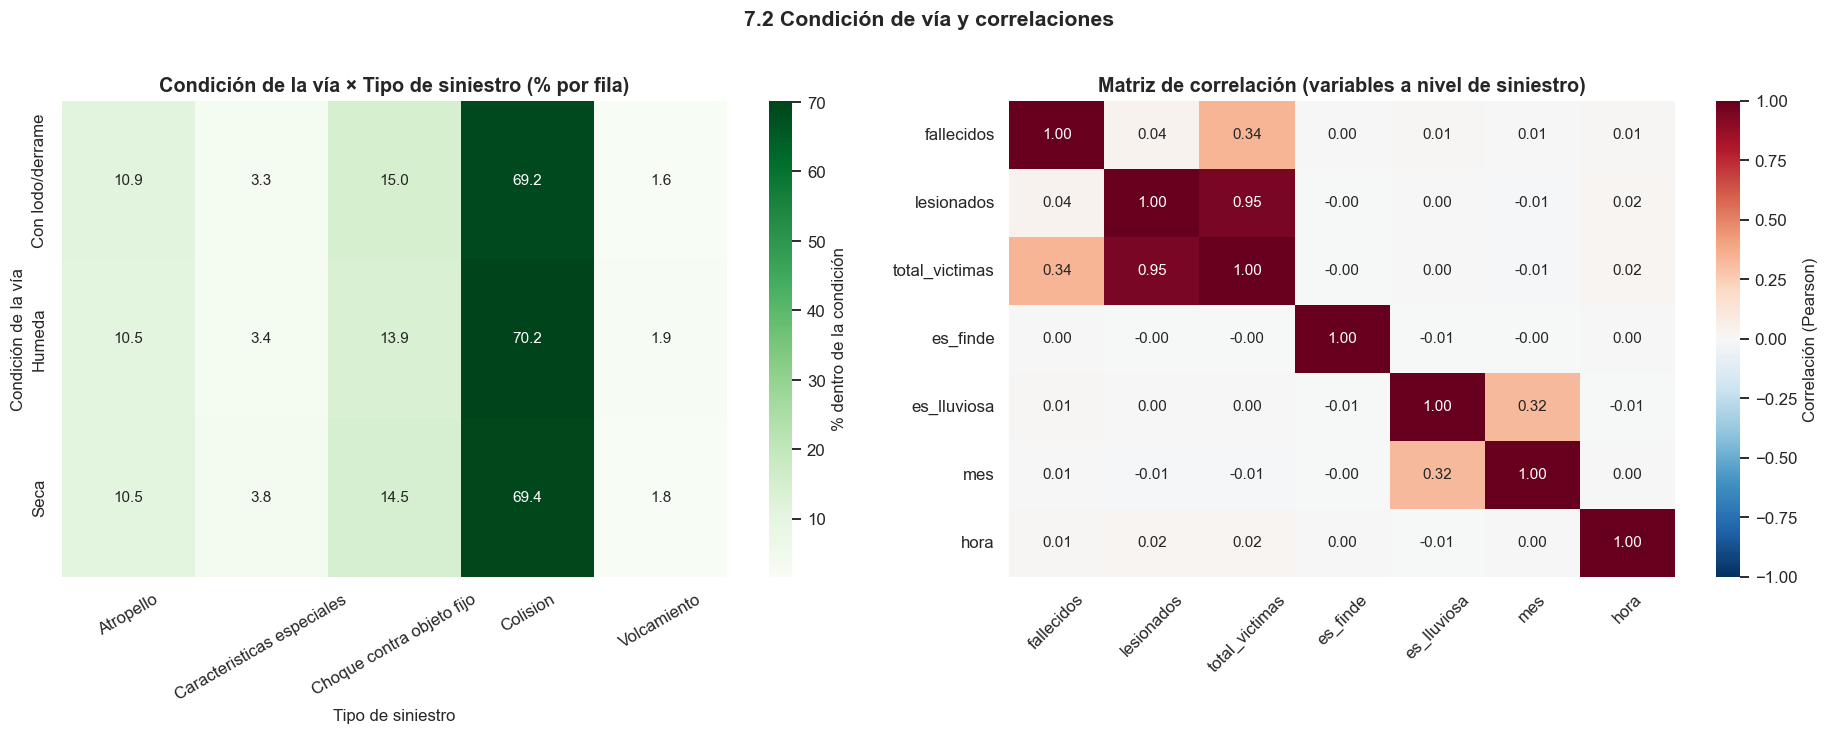

Condición de la vía × tipo de siniestro (% por fila):
tipo_siniestro    Atropello  Caracteristicas especiales  Choque contra objeto fijo  Colision  Volcamiento
condicion_via                                                                                            
Con lodo/derrame      10.92                        3.27                      14.97     69.20         1.64
Humeda                10.50                        3.41                      13.95     70.20         1.95
Seca                  10.51                        3.75                      14.51     69.41         1.82


In [34]:
# --- 7.2 (1) condicion_via × tipo_siniestro ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

ct3 = pd.crosstab(siniestros["condicion_via"], siniestros["tipo_siniestro"],
                  normalize="index") * 100
sns.heatmap(ct3, annot=True, fmt=".1f", cmap="Greens", ax=axes[0],
            cbar_kws={"label": "% dentro de la condición"})
axes[0].set_title("Condición de la vía × Tipo de siniestro (% por fila)")
axes[0].set_xlabel("Tipo de siniestro")
axes[0].set_ylabel("Condición de la vía")
axes[0].tick_params(axis="x", rotation=30)

# --- 7.2 (2) Matriz de correlación de variables numéricas / derivadas ---
# Construcción de un DataFrame exploratorio a nivel de siniestro
df_num = siniestros.copy()
df_num["mes"] = df_num["fecha"].dt.month
df_num["dow"] = df_num["fecha"].dt.dayofweek
df_num["es_finde"] = df_num["dow"].isin([4, 5]).astype(int)      # vie/sáb
df_num["es_lluviosa"] = df_num["mes"].isin(range(5, 11)).astype(int)
df_num["hora"] = df_num["fecha_hora"].dt.hour
df_num["total_victimas"] = df_num["fallecidos"] + df_num["lesionados"]

cols_corr = ["fallecidos", "lesionados", "total_victimas",
             "es_finde", "es_lluviosa", "mes", "hora"]
corr = df_num[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            vmin=-1, vmax=1, cbar_kws={"label": "Correlación (Pearson)"})
axes[1].set_title("Matriz de correlación (variables a nivel de siniestro)")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("7.2 Condición de vía y correlaciones", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_7_2_condicion_correlacion")
plt.show()

# Print de apoyo
print("Condición de la vía × tipo de siniestro (% por fila):")
print(ct3.round(2).to_string())

### 7.3 Síntesis de relaciones bivariadas

- **Zona × tipo de siniestro** y **condición de vía × tipo de siniestro**: ambos cruces resultan
  prácticamente uniformes: la composición de tipos de siniestro no varía de forma apreciable entre
  zonas urbanas/rurales ni entre condiciones de la vía. En este conjunto, esas variables son
  aproximadamente independientes del tipo de siniestro, lo que se tiene en cuenta al no esperar
  interacción de ese cruce en el modelado.
- **Franja horaria × severidad**: es el cruce con mayor señal. La **madrugada (00–05 h)** presenta
  la mayor proporción de siniestros con fallecido (11.3%), más del doble que la mañana (4.6%) o la
  tarde (5.4%), pese a ser la franja de menor volumen. La franja horaria es, por tanto, una
  variable relevante para la severidad.
- **Matriz de correlación**: las asociaciones lineales fuertes son estructurales
  (`lesionados`–`total_victimas`, `es_lluviosa`–`mes`). La severidad muestra correlación de
  Pearson cercana a cero con los indicadores temporales **a nivel de siniestro individual**; esto
  no implica ausencia de relación, sino que la correlación lineal sobre conteos cero-inflados no
  es el instrumento adecuado: la relación (p. ej. franja–severidad) se manifiesta al **agregar** o
  mediante **modelos de conteo**.

**Decisiones para NB03**:
- Evitar incluir simultáneamente `mes` y `es_lluviosa` (redundancia, r ≈ 0.32).
- No descartar variables temporales por su baja correlación lineal a nivel de evento; su efecto
  sobre la severidad requiere agregación o modelos de conteo para hacerse visible.

## 8. Diagnóstico de sobredispersión

El modelado de la frecuencia de siniestros (NB04) se plantea sobre datos de **conteo**: número de
siniestros por unidad de análisis (distrito × período). La elección del modelo de conteo depende
de una propiedad clave de esos datos: la relación entre su **media** y su **varianza**.

- La **Regresión de Poisson** asume *equidispersión*: varianza = media.
- Cuando la varianza **supera** a la media (*sobredispersión*), Poisson subestima la variabilidad y
  se prefiere la **Binomial Negativa**, que incorpora un parámetro adicional para modelar ese
  exceso.

El criterio formal de selección (AIC) se aplica en NB04. Aquí se realiza el **diagnóstico
exploratorio**: verificar si el conteo agregado presenta sobredispersión y con qué magnitud.

**Un punto importante sobre la resolución.** Como se observó en la Sección 2.3, a nivel de
siniestro individual las variables de severidad están cerca de la equidispersión. La
sobredispersión relevante para el modelado **emerge al agregar** los eventos en una grilla
(distrito × período), porque la agregación combina zonas y períodos muy heterogéneos —muchas
celdas con pocos o cero siniestros y algunas con muchos—. Por ello el diagnóstico se hace sobre el
**conteo agregado**, que es la forma en que los datos entrarán al modelo, y no sobre el evento
suelto.

El índice de dispersión se calcula como **ID = varianza / media**: ID ≈ 1 indica equidispersión
(Poisson); ID > 1 indica sobredispersión (Binomial Negativa).

/var/folders/vr/117fzs5j7g36v1wtxyh0544w0000gp/T/ipykernel_19679/1152673390.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(niveles, rotation=15)


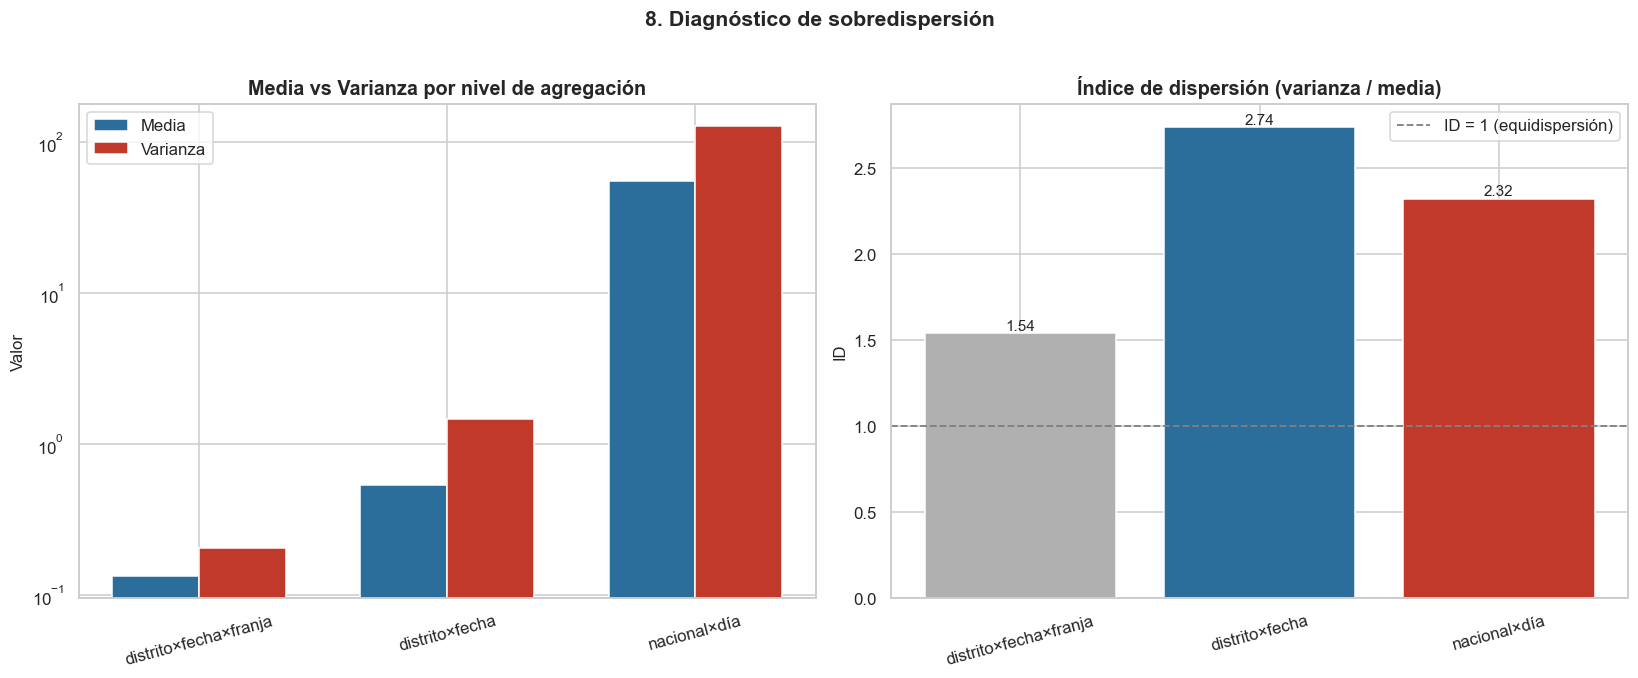

Diagnóstico de sobredispersión (ID = varianza / media):

  distrito×fecha×franja   : media=  0.1330  var=    0.2048  ID=  1.54
  distrito×fecha          : media=  0.5318  var=    1.4569  ID=  2.74
  nacional×día            : media= 54.7783  var=  127.3293  ID=  2.32

  ID ≈ 1 -> Poisson (equidispersión)
  ID > 1 -> Binomial Negativa (sobredispersión)


In [35]:
# --- 8. Diagnóstico de sobredispersión sobre el conteo agregado ---
# Se construye una grilla EXPLORATORIA distrito × fecha × franja con conteo de siniestros,
# rellenando con CERO las combinaciones sin siniestros (clave para el diagnóstico honesto).
# NOTA: esta grilla es exploratoria; la versión reproducible se construye en NB03.

sin = siniestros.assign(fecha_norm=siniestros["fecha"].dt.normalize())

# Universo de combinaciones posibles: distritos × fechas × franjas observadas
distritos = sin["distrito"].unique()
fechas = pd.date_range(sin["fecha_norm"].min(), sin["fecha_norm"].max(), freq="D")
franjas = sin["franja_horaria"].unique()

# Conteo observado por celda
conteo_obs = (sin.groupby(["distrito", "fecha_norm", "franja_horaria"])
                 .size().rename("n").reset_index())

# Total de celdas posibles (con ceros incluidos)
n_celdas_posibles = len(distritos) * len(fechas) * len(franjas)

# Estadísticos con ceros: la media y varianza sobre TODAS las celdas posibles
suma_conteos = conteo_obs["n"].sum()
suma_cuadrados = (conteo_obs["n"] ** 2).sum()

media_con_ceros = suma_conteos / n_celdas_posibles
# var = E[X^2] - E[X]^2 ; E[X^2] = suma_cuadrados / N (los ceros no aportan al numerador)
media_cuadrados = suma_cuadrados / n_celdas_posibles
var_con_ceros = media_cuadrados - media_con_ceros ** 2
id_con_ceros = var_con_ceros / media_con_ceros

# --- Comparación a tres niveles de agregación ---
resultados = {}

# (1) Grilla fina: distrito × fecha × franja (con ceros)
resultados["distrito×fecha×franja"] = (media_con_ceros, var_con_ceros, id_con_ceros)

# (2) Agregación media: distrito × fecha (con ceros)
conteo_df = (sin.groupby(["distrito", "fecha_norm"]).size().rename("n").reset_index())
n_pos_2 = len(distritos) * len(fechas)
m2 = conteo_df["n"].sum() / n_pos_2
v2 = (conteo_df["n"] ** 2).sum() / n_pos_2 - m2 ** 2
resultados["distrito×fecha"] = (m2, v2, v2 / m2)

# (3) Agregación gruesa: total nacional por día (sin ceros estructurales relevantes)
conteo_dia = sin.groupby("fecha_norm").size()
m3, v3 = conteo_dia.mean(), conteo_dia.var()
resultados["nacional×día"] = (m3, v3, v3 / m3)

# --- Gráfico: media vs varianza por nivel + índice de dispersión ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax0 = axes[0]
niveles = list(resultados.keys())
medias = [resultados[k][0] for k in niveles]
varianzas = [resultados[k][1] for k in niveles]
x = np.arange(len(niveles))
w = 0.35
ax0.bar(x - w/2, medias, w, label="Media", color=COLOR_PRINCIPAL)
ax0.bar(x + w/2, varianzas, w, label="Varianza", color=COLOR_ACENTO)
ax0.set_xticks(x)
ax0.set_xticklabels(niveles, rotation=15)
ax0.set_title("Media vs Varianza por nivel de agregación")
ax0.set_ylabel("Valor")
ax0.legend()
ax0.set_yscale("log")  # escalas muy distintas entre niveles

ax1 = axes[1]
ids = [resultados[k][2] for k in niveles]
barras = ax1.bar(niveles, ids, color=[COLOR_PARCIAL, COLOR_PRINCIPAL, COLOR_ACENTO])
ax1.axhline(1, color="gray", linestyle="--", linewidth=1.2, label="ID = 1 (equidispersión)")
for b, v in zip(barras, ids):
    ax1.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax1.set_title("Índice de dispersión (varianza / media)")
ax1.set_ylabel("ID")
ax1.set_xticklabels(niveles, rotation=15)
ax1.legend()

fig.suptitle("8. Diagnóstico de sobredispersión", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
cfg.save_fig(fig, "nb02_8_sobredispersion")
plt.show()

print("Diagnóstico de sobredispersión (ID = varianza / media):\n")
for k in niveles:
    m, v, idx = resultados[k]
    print(f"  {k:<24}: media={m:8.4f}  var={v:10.4f}  ID={idx:6.2f}")
print("\n  ID ≈ 1 -> Poisson (equidispersión)")
print("  ID > 1 -> Binomial Negativa (sobredispersión)")

### 8.1 Síntesis del diagnóstico de sobredispersión

El conteo de siniestros presenta **sobredispersión** (varianza > media) en todos los niveles de
agregación evaluados, confirmando que la Regresión de Poisson (que asume equidispersión) es
insuficiente y que procede compararla con la **Binomial Negativa**:

| Nivel de agregación | Índice de dispersión (var/media) |
| --- | --- |
| distrito × fecha × franja | 1.54 |
| distrito × fecha | 2.74 |
| nacional × día | 2.32 |

**Lecturas principales**:

- La sobredispersión **no es un valor único**: depende de la resolución de agregación. El índice
  crece de la grilla más fina (1.54, dominada por celdas 0/1) al nivel distrito × fecha (2.74),
  donde la heterogeneidad entre distritos —unos con muchos siniestros, otros con casi ninguno— es
  máxima. Este comportamiento es consistente con la teoría: la sobredispersión surge de la
  heterogeneidad entre unidades de análisis.
- El nivel **distrito × fecha (ID = 2.74)** es el más representativo de la estructura que
  enfrentará el modelo y respalda cuantitativamente la elección de la Binomial Negativa.

**Decisión para NB04**: comparar Regresión de Poisson vs Binomial Negativa mediante AIC, con la
expectativa —fundada en este diagnóstico— de que la Binomial Negativa ofrezca mejor ajuste. La
resolución de agregación de la grilla de modelado se define en NB03 teniendo en cuenta que
condiciona el grado de sobredispersión observado.

## 9. Síntesis final del EDA

Este notebook caracterizó la siniestralidad vial de El Salvador (2022–jun 2026) cruzando la capa
de eventos con fuentes reales de contexto (Censo 2024, calendario de feriados y clima horario de
Meteostat). Los hallazgos principales se resumen a continuación.

### 9.1 Hallazgos consolidados

**Temporales**

- Crecimiento sostenido de la siniestralidad 2022–2025; el primer semestre de 2026 mantiene la
  tendencia (+8.4% homólogo vs 2025).
- La temporada lluviosa (May–Oct) concentra ~16% más siniestros que la seca.
- Pico semanal en viernes y sábado; valle a mitad de semana.
- Concentración horaria en la tarde (12–17 h, ~37%); mínimo en la madrugada.
- Los días feriados presentan +25% de siniestros. Entre los períodos de calendario, solo las
  fiestas agostinas muestran un pico marcado (+32% vs promedio anual).

**Espaciales**

- San Salvador y La Libertad concentran el 48.7% de los siniestros (nivel departamental).
- El conteo bruto y la tasa per cápita producen rankings distintos (solo 3 de 15 distritos
  coinciden): normalizar por exposición aporta información que el conteo absoluto oculta.
- Tres zonas calientes en el mapa de densidad: AMSS (la mayor), San Miguel y Santa Ana.

**Víctimas y severidad**

- Usuarios de motocicleta (42.0%) y peatones (34.2%) concentran más de tres cuartas partes de las
  víctimas fatales.
- El peatón es el usuario más letal (18.0% de sus víctimas fallecen); el ocupante de vehículo
  cerrado, el más protegido (3.7%).
- El volumen de víctimas se concentra en 21–35 años, pero la letalidad crece con la edad (máximo
  en 71+: 24.8%).
- La madrugada es la franja más letal (11.3% de siniestros con fallecido), pese a su bajo volumen.

**Clima**

- La relación clima–siniestralidad es fuerte a nivel estacional (r = 0.81 mensual) y se diluye al
  nivel diario (r = 0.30 nacional; ≈ 0 a distrito×día): la señal climática vive a resolución de
  temporada, que es la relevante para el modelado.

**Dispersión**

- El conteo de siniestros presenta sobredispersión en todos los niveles de agregación (ID de 1.54
  a 2.74), con máximo en distrito × fecha. La magnitud depende de la resolución de agregación.

### 9.2 Decisiones que se trasladan al preprocesamiento y modelado

**Para NB03 (preprocesamiento y feature engineering)**

- **Grilla de modelado**: construir la grilla distrito × fecha × franja con celdas en cero, base
  del conteo a modelar. La resolución elegida condiciona el grado de sobredispersión (ver §8).
- **Variables de calendario**: mes, indicador de temporada lluviosa, indicador de fin de semana
  (vie/sáb), franja horaria, indicador de feriado y de período agostino.
- **Colinealidad**: no incluir simultáneamente `mes` y `es_lluviosa` (r ≈ 0.32); elegir una.
- **Exposición**: construir un denominador más completo que la población residente, incorporando
  el parque vehicular por distrito. Filtrar o señalar distritos de población muy baja para evitar
  tasas volátiles.
- **Clima**: incorporar la variable climática a resolución **estacional/mensual** (temporada
  lluviosa y/o precipitación agregada del período), reutilizando el *join* distrito→estación por
  cercanía construido en §6. No usar precipitación diaria puntual como predictor.
- **Categóricas**: agrupar la cola de baja frecuencia de `factor_causante` (las causas fuera del
  80% acumulado) y las categorías minoritarias de `tipo_siniestro` y `tipo_vehiculo`.
- **Variables de severidad**: `grupo_vulnerable` (motociclista/peatón/ciclista/otro) y rango
  etario como caracterizadores de la severidad.
- **Targets**: `n_siniestros` (regresión de conteo) y `nivel_riesgo` (clasificación).

**Para NB04 (modelos baseline)**

- **Modelos de conteo**: comparar Regresión de Poisson vs Binomial Negativa mediante AIC; el
  diagnóstico de §8 anticipa mejor ajuste de la Binomial Negativa.
- **Baselines**: predictor ingenuo (media), modelo lineal/GLM y Random Forest como mínimo.
- **Métricas**: MAE/RMSE para regresión; accuracy/F1 para clasificación.
- **Interpretabilidad**: SHAP para identificar las variables de mayor influencia.
- **No descartar variables temporales** por baja correlación lineal a nivel de evento: su efecto
  se manifiesta al agregar o mediante modelos de conteo (ver §7).